## 0.  Bootstrap the `src/` package (self-contained)

The single cell below writes every module of the SLAM-ASR source
package to `/kaggle/working/src/`, then adds the working directory
to `sys.path` — so the rest of the notebook can use standard
imports like

```python
from src.data.text_normalization import CodeSwitchTextNormalizer
```

**No GitHub clone, no extra dataset upload for source code is
required.**


In [1]:
# ─── SETUP: write the `src/` package to /kaggle/working/src/ ─────────────────
# This cell is 100% self-contained — no GitHub clone, no attached dataset for
# source code.  It stores every file of the SLAM-ASR package in a JSON blob
# and materialises them on the Kaggle disk, then adds /kaggle/working to the
# Python path.  After this cell, `from src.data ...` works as if the repo
# were cloned.
import json, os, sys, pathlib, textwrap

SRC_FILES_JSON = r"""{"src/__init__.py": "\"\"\"SLAM-ASR source package for Hindi-English code-switched speech recognition.\"\"\"\n\n__version__ = \"0.1.0\"\n", "src/data/__init__.py": "\"\"\"Data-side utilities: manifest handling, PyTorch datasets, text normalisation.\"\"\"\n\nfrom .manifest_utils import (\n    load_manifest,\n    save_manifest,\n    rewrite_manifest_paths,\n    manifest_statistics,\n)\nfrom .text_normalization import CodeSwitchTextNormalizer\nfrom .dataset import MUCSDataset, WhisperCollator, SlamASRCollator\n\n__all__ = [\n    \"load_manifest\",\n    \"save_manifest\",\n    \"rewrite_manifest_paths\",\n    \"manifest_statistics\",\n    \"CodeSwitchTextNormalizer\",\n    \"MUCSDataset\",\n    \"WhisperCollator\",\n    \"SlamASRCollator\",\n]\n", "src/data/manifest_utils.py": "\"\"\"Manifest loading, path rewriting, and dataset statistics.\n\nThe MUCS manifests are JSON-Lines files with one entry per utterance:\n\n    {\"audio_path\": \"/home/.../654444_0049FmqkWQMNW6Tc_0000.wav\",\n     \"text\": \"meet the gimp के spoken tutorial में आपका स्वागत है\",\n     \"speaker\": \"654444\",\n     \"duration\": 3.0,\n     \"cut_id\": \"654444_0049FmqkWQMNW6Tc_0000\"}\n\nThe upstream manifests point to the dataset author's local machine, so we\nprovide `rewrite_manifest_paths` to relocate them to (a) the local repo\ncopy or (b) Kaggle-hosted paths.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport re\nimport unicodedata\nfrom collections import Counter\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom typing import Any, Dict, Iterable, List, Optional\n\n# ---------------------------------------------------------------------------\n# JSONL I/O\n# ---------------------------------------------------------------------------\n\n\ndef load_manifest(path: str | Path) -> List[Dict[str, Any]]:\n    \"\"\"Load a JSONL manifest into a list of dictionaries.\n\n    Parameters\n    ----------\n    path:\n        Path to a ``.jsonl`` file.\n\n    Returns\n    -------\n    list of dict\n        One dictionary per line; malformed lines are skipped with a warning.\n    \"\"\"\n    entries: List[Dict[str, Any]] = []\n    path = Path(path)\n    with path.open(\"r\", encoding=\"utf-8\") as fh:\n        for i, line in enumerate(fh, start=1):\n            line = line.strip()\n            if not line:\n                continue\n            try:\n                entries.append(json.loads(line))\n            except json.JSONDecodeError as err:\n                print(f\"[manifest] skipping malformed line {i} in {path}: {err}\")\n    return entries\n\n\ndef save_manifest(entries: Iterable[Dict[str, Any]], path: str | Path) -> None:\n    \"\"\"Serialise an iterable of dicts back to JSONL.\"\"\"\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    with path.open(\"w\", encoding=\"utf-8\") as fh:\n        for entry in entries:\n            fh.write(json.dumps(entry, ensure_ascii=False) + \"\\n\")\n\n\n# ---------------------------------------------------------------------------\n# Path rewriting\n# ---------------------------------------------------------------------------\n\n\ndef _speaker_from_cut_id(cut_id: str) -> str:\n    \"\"\"Extract the leading speaker/session token from ``cut_id`` (before ``_``).\"\"\"\n    return cut_id.split(\"_\", 1)[0]\n\n\ndef rewrite_manifest_paths(\n    entries: List[Dict[str, Any]],\n    old_prefix: str,\n    new_root: str,\n    split: str,\n    add_speaker_subdir: bool = True,\n) -> List[Dict[str, Any]]:\n    \"\"\"Rewrite the ``audio_path`` field of every entry to a new root.\n\n    The upstream MUCS manifests point at\n    ``/home/puneets/suksham-mucs/mucs/data/processed/<split>/<file>.wav``.\n    Our on-disk layout is\n    ``<new_root>/data/processed/<split>/<speaker3>/<file>.wav`` — the extra\n    ``<speaker3>`` sub-directory is the first three characters of the\n    speaker id (see the local ``datasets/mucs/data/processed/train/``\n    directory listing).\n\n    Parameters\n    ----------\n    entries:\n        List of manifest rows.\n    old_prefix:\n        Prefix in the current ``audio_path`` that must be replaced.\n    new_root:\n        Replacement root, e.g. ``datasets/mucs`` or\n        ``/kaggle/input/mucs-2021-hindi-english-code-switched-speech/mucs``.\n    split:\n        Split name (``train`` / ``test`` / ``blindtest``) — used to insert\n        the correct three-digit sub-directory.\n    add_speaker_subdir:\n        Whether to add the ``<first-three-digits-of-speaker>/`` intermediate\n        directory. Set to ``False`` if audio is stored flat under the split.\n\n    Returns\n    -------\n    list of dict\n        Deep-copied entries with corrected ``audio_path`` fields.\n    \"\"\"\n    fixed: List[Dict[str, Any]] = []\n    for row in entries:\n        row = dict(row)\n        p = row.get(\"audio_path\") or row.get(\"source\") or \"\"\n        if old_prefix and p.startswith(old_prefix):\n            p = p.replace(old_prefix, new_root, 1)\n        # Insert speaker three-digit sub-directory if not already present.\n        if add_speaker_subdir:\n            filename = Path(p).name\n            spk3 = filename.split(\"_\", 1)[0][:3]\n            if f\"/{split}/{spk3}/\" not in p:\n                # Replace .../processed/<split>/<file>.wav with .../processed/<split>/<spk3>/<file>.wav\n                p = re.sub(\n                    rf\"/processed/{split}/(?!(?:\\d{{3}})/)([^/]+\\.wav)$\",\n                    rf\"/processed/{split}/{spk3}/\\1\",\n                    p,\n                )\n        if \"audio_path\" in row:\n            row[\"audio_path\"] = p\n        if \"source\" in row:\n            row[\"source\"] = p\n        fixed.append(row)\n    return fixed\n\n\n# ---------------------------------------------------------------------------\n# Statistics\n# ---------------------------------------------------------------------------\n\n\nDEVANAGARI_RE = re.compile(r\"[\\u0900-\\u097F]\")\nROMAN_RE = re.compile(r\"[A-Za-z]\")\n\n\ndef _script_of_word(word: str) -> str:\n    \"\"\"Return one of {``hi``, ``en``, ``mixed``, ``other``} for a token.\"\"\"\n    has_dev = bool(DEVANAGARI_RE.search(word))\n    has_rom = bool(ROMAN_RE.search(word))\n    if has_dev and has_rom:\n        return \"mixed\"\n    if has_dev:\n        return \"hi\"\n    if has_rom:\n        return \"en\"\n    return \"other\"\n\n\n@dataclass\nclass ManifestStats:\n    \"\"\"Container for the human-readable statistics printed by ``manifest_statistics``.\"\"\"\n\n    n_utterances: int\n    n_speakers: int\n    total_duration_h: float\n    mean_duration_s: float\n    median_duration_s: float\n    n_tokens: int\n    n_unique_tokens: int\n    frac_hindi_tokens: float\n    frac_english_tokens: float\n    frac_mixed_tokens: float\n    frac_code_switched_utterances: float\n\n\ndef manifest_statistics(entries: List[Dict[str, Any]]) -> ManifestStats:\n    \"\"\"Compute descriptive statistics used in the EDA notebook and report.\n\n    In particular, we report the fraction of utterances that are\n    *code-switched* — i.e., contain at least one Hindi and at least one\n    English word — which is the core motivator for this project.\n    \"\"\"\n    speakers: set[str] = set()\n    durations: List[float] = []\n    all_tokens: List[str] = []\n    hi_tokens = en_tokens = mx_tokens = 0\n    n_cs_utts = 0\n\n    for row in entries:\n        text = row.get(\"text\") or row.get(\"target\") or \"\"\n        text_nfc = unicodedata.normalize(\"NFC\", text)\n        tokens = text_nfc.split()\n        all_tokens.extend(tokens)\n        scripts = [_script_of_word(t) for t in tokens]\n        n_hi = sum(1 for s in scripts if s == \"hi\")\n        n_en = sum(1 for s in scripts if s == \"en\")\n        n_mx = sum(1 for s in scripts if s == \"mixed\")\n        hi_tokens += n_hi\n        en_tokens += n_en\n        mx_tokens += n_mx\n        if n_hi > 0 and n_en > 0:\n            n_cs_utts += 1\n        speakers.add(str(row.get(\"speaker\", \"\")))\n        durations.append(float(row.get(\"duration\", 0.0)))\n\n    n_tokens = len(all_tokens)\n    n_utts = len(entries)\n    durations_sorted = sorted(durations)\n    median = durations_sorted[len(durations_sorted) // 2] if durations_sorted else 0.0\n\n    return ManifestStats(\n        n_utterances=n_utts,\n        n_speakers=len(speakers),\n        total_duration_h=sum(durations) / 3600.0,\n        mean_duration_s=sum(durations) / max(n_utts, 1),\n        median_duration_s=median,\n        n_tokens=n_tokens,\n        n_unique_tokens=len(set(all_tokens)),\n        frac_hindi_tokens=hi_tokens / max(n_tokens, 1),\n        frac_english_tokens=en_tokens / max(n_tokens, 1),\n        frac_mixed_tokens=mx_tokens / max(n_tokens, 1),\n        frac_code_switched_utterances=n_cs_utts / max(n_utts, 1),\n    )\n\n\n# ---------------------------------------------------------------------------\n# CLI: `python -m src.data.manifest_utils --manifest ... --stats`\n# ---------------------------------------------------------------------------\n\n\ndef _cli() -> None:\n    parser = argparse.ArgumentParser(description=\"Inspect a MUCS manifest.\")\n    parser.add_argument(\"--manifest\", required=True, help=\"Path to JSONL manifest.\")\n    parser.add_argument(\"--stats\", action=\"store_true\", help=\"Print dataset statistics.\")\n    parser.add_argument(\n        \"--rewrite-to\", default=None,\n        help=\"If provided, rewrite audio paths to this root and write output next to input.\",\n    )\n    parser.add_argument(\"--old-prefix\", default=\"/home/puneets/suksham-mucs/mucs\")\n    parser.add_argument(\"--split\", default=None,\n                        help=\"Split name (train/test/blindtest). Auto-detected from filename if omitted.\")\n    args = parser.parse_args()\n\n    entries = load_manifest(args.manifest)\n    print(f\"Loaded {len(entries)} entries from {args.manifest}\")\n\n    if args.stats:\n        stats = manifest_statistics(entries)\n        for field, value in stats.__dict__.items():\n            if isinstance(value, float):\n                print(f\"  {field:35s} = {value:.4f}\")\n            else:\n                print(f\"  {field:35s} = {value}\")\n\n    if args.rewrite_to:\n        split = args.split or Path(args.manifest).parent.name\n        rewritten = rewrite_manifest_paths(entries, args.old_prefix, args.rewrite_to, split)\n        out = Path(args.manifest).with_suffix(\".rewritten.jsonl\")\n        save_manifest(rewritten, out)\n        print(f\"Wrote rewritten manifest to {out}\")\n\n\nif __name__ == \"__main__\":  # pragma: no cover\n    _cli()\n", "src/data/text_normalization.py": "\"\"\"Text normalisation for Hindi-English code-switched transcripts.\n\nWER numbers can swing wildly depending on how aggressively you normalise the\nreference and hypothesis strings.  For the MUCS challenge the community\nstandard is:\n\n1. Unicode NFC normalisation (so ``क + ि`` matches ``कि``).\n2. Lower-case Roman characters; leave Devanagari unchanged.\n3. Convert Devanagari digits to Roman digits (``१२३`` → ``123``).\n4. Remove punctuation and control characters.\n5. Collapse whitespace.\n6. Optionally strip Hindi/English filler words (``uh``, ``um``, ``अं``).\n\nThe normaliser is *deterministic* and *idempotent* — running it twice\nproduces the same output as running it once.  This is essential for\nreproducible WER reporting.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport re\nimport unicodedata\nfrom dataclasses import dataclass\nfrom typing import Iterable, List\n\n# Devanagari digits 0-9  →  Roman digits 0-9\n_DEVANAGARI_DIGIT_MAP = str.maketrans(\"०१२३४५६७८९\", \"0123456789\")\n\n# Characters that we treat as punctuation / non-linguistic decoration.\n# We keep the ASCII hyphen because \"e-mail\" or \"c-plus-plus\" is a token\n# in this technical corpus, but we replace it with a space so WER counts\n# each half separately (matches the challenge convention).\n_PUNCTUATION_RE = re.compile(\n    r\"[!\\\"#\\$%&'()*+,\\-./:;<=>?@\\[\\\\\\]^_`{|}~।॥\\u2013\\u2014\\u2018\\u2019\\u201c\\u201d]\"\n)\n\n# Extra whitespace collapse\n_WHITESPACE_RE = re.compile(r\"\\s+\")\n\n# Common filler tokens (Hindi + English)\n_DEFAULT_FILLERS = {\n    \"uh\", \"um\", \"hmm\", \"mm\", \"mhm\", \"err\", \"ah\", \"eh\",\n    \"अं\", \"आं\", \"ओं\", \"उम\", \"एर\", \"अरे\",\n}\n\n\n@dataclass\nclass CodeSwitchTextNormalizer:\n    \"\"\"Idempotent text normaliser for MUCS Hindi-English transcripts.\n\n    Parameters\n    ----------\n    lowercase_roman:\n        Lower-case ASCII / Latin characters.  Devanagari has no case.\n    map_devanagari_digits:\n        Replace ``०–९`` with ``0–9``.\n    remove_punctuation:\n        Strip characters listed in :data:`_PUNCTUATION_RE`.\n    remove_fillers:\n        Drop tokens matching :attr:`fillers` (default: common HI + EN fillers).\n    fillers:\n        Iterable of tokens to remove (matched after tokenisation).  Set to\n        ``None`` to use the default list; pass an empty set to disable.\n    \"\"\"\n\n    lowercase_roman: bool = True\n    map_devanagari_digits: bool = True\n    remove_punctuation: bool = True\n    remove_fillers: bool = False\n    fillers: Iterable[str] | None = None\n\n    def __post_init__(self) -> None:\n        self._fillers = set(self.fillers) if self.fillers is not None else _DEFAULT_FILLERS\n\n    # ---------------------------------------------------------------- API\n    def __call__(self, text: str) -> str:\n        \"\"\"Normalise a single string.\"\"\"\n        return self.normalize(text)\n\n    def normalize(self, text: str) -> str:\n        \"\"\"Return the canonicalised form of *text*.\"\"\"\n        if text is None:\n            return \"\"\n        # 1) Unicode canonical composition — combining marks + base characters.\n        text = unicodedata.normalize(\"NFC\", text)\n\n        # 2) Roman lower-case (leaves Devanagari alone).\n        if self.lowercase_roman:\n            text = text.lower()\n\n        # 3) Devanagari digits -> Roman digits.\n        if self.map_devanagari_digits:\n            text = text.translate(_DEVANAGARI_DIGIT_MAP)\n\n        # 4) Punctuation stripping.\n        if self.remove_punctuation:\n            text = _PUNCTUATION_RE.sub(\" \", text)\n\n        # 5) Tokenise, optionally remove fillers.\n        tokens = text.split()\n        if self.remove_fillers and self._fillers:\n            tokens = [t for t in tokens if t not in self._fillers]\n\n        # 6) Collapse whitespace.\n        return _WHITESPACE_RE.sub(\" \", \" \".join(tokens)).strip()\n\n    def batch_normalize(self, texts: Iterable[str]) -> List[str]:\n        \"\"\"Normalise many strings; convenience wrapper.\"\"\"\n        return [self.normalize(t) for t in texts]\n\n\n# ------------------------- Quick self-test -------------------------\nif __name__ == \"__main__\":  # pragma: no cover\n    norm = CodeSwitchTextNormalizer(remove_fillers=True)\n    samples = [\n        \"Meet the GIMP के Spoken Tutorial में आपका स्वागत है।\",\n        \"अध्याय १२३ - Introduction to Python?\",\n        \"uh yeh tutorial hai... um okay\",\n    ]\n    for s in samples:\n        print(f\"{s!r}\\n  -> {norm(s)!r}\")\n", "src/data/dataset.py": "\"\"\"PyTorch dataset & collators for MUCS Hindi-English code-switched ASR.\n\nThree consumers are supported:\n\n* :class:`MUCSDataset` — thin ``torch.utils.data.Dataset`` that lazily loads\n  a waveform + reference transcript from a manifest row.  Optional on-the-fly\n  duration filtering and text normalisation.\n\n* :class:`WhisperCollator` — batches raw waveforms into 80-mel log-Mel\n  features + tokenised targets using a HuggingFace\n  ``WhisperProcessor``.  Used by the Whisper-only baseline (notebook 5).\n\n* :class:`SlamASRCollator` — the collator that powers the full SLAM-ASR\n  model.  It produces (a) Whisper input features, (b) tokenised LLM\n  ``input_ids`` for the prompt + target, and (c) a mask that tells the\n  training loop which positions must be replaced with projected audio\n  embeddings at forward time.\n\nAll collators expect the config dictionary described in\n``configs/slam_asr.yaml``.\n\"\"\"\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom typing import Any, Callable, Dict, List, Optional\n\nimport numpy as np\nimport torch\nfrom torch.utils.data import Dataset\n\nfrom .manifest_utils import load_manifest\nfrom .text_normalization import CodeSwitchTextNormalizer\n\ntry:\n    import soundfile as sf\nexcept ImportError as _err:  # pragma: no cover\n    sf = None\n    _SF_IMPORT_ERROR = _err\n\n\n# ---------------------------------------------------------------------------\n# Dataset\n# ---------------------------------------------------------------------------\n\n\nclass MUCSDataset(Dataset):\n    \"\"\"PyTorch dataset over a MUCS manifest.\n\n    Parameters\n    ----------\n    manifest_path:\n        Path to a JSONL manifest.  Each row must have ``audio_path`` and\n        ``text`` (or ``source`` / ``target``) fields.\n    sample_rate:\n        Expected sample rate.  If the audio file uses a different rate a\n        cheap fallback resampler is used (librosa if available, else raise).\n    min_duration_s, max_duration_s:\n        Filter out utterances outside this range at load time.\n    normalizer:\n        Optional :class:`CodeSwitchTextNormalizer`.  Passing one guarantees\n        the returned ``text`` matches the reference used at evaluation.\n    audio_path_prefix:\n        Optional prefix prepended to relative ``audio_path`` fields (useful\n        when the manifest has been rewritten to relative paths).\n    \"\"\"\n\n    def __init__(\n        self,\n        manifest_path: str | Path,\n        sample_rate: int = 16000,\n        min_duration_s: float = 0.5,\n        max_duration_s: float = 30.0,\n        normalizer: Optional[CodeSwitchTextNormalizer] = None,\n        audio_path_prefix: Optional[str] = None,\n    ) -> None:\n        super().__init__()\n        if sf is None:  # pragma: no cover\n            raise ImportError(f\"soundfile is required to load audio: {_SF_IMPORT_ERROR}\")\n\n        raw = load_manifest(manifest_path)\n        # Filter by duration.\n        self.entries: List[Dict[str, Any]] = [\n            r for r in raw\n            if min_duration_s <= float(r.get(\"duration\", max_duration_s)) <= max_duration_s\n        ]\n        self.sample_rate = sample_rate\n        self.normalizer = normalizer\n        self.audio_path_prefix = audio_path_prefix\n\n    def __len__(self) -> int:\n        return len(self.entries)\n\n    def _resolve_path(self, row: Dict[str, Any]) -> str:\n        p = row.get(\"audio_path\") or row.get(\"source\") or \"\"\n        if self.audio_path_prefix and not p.startswith(\"/\") and not p.startswith(str(self.audio_path_prefix)):\n            p = str(Path(self.audio_path_prefix) / p)\n        return p\n\n    def _load_audio(self, path: str) -> np.ndarray:\n        \"\"\"Load audio from disk, resample if needed, return mono float32 in [-1, 1].\"\"\"\n        audio, sr = sf.read(path, dtype=\"float32\", always_2d=False)\n        if audio.ndim > 1:\n            audio = audio.mean(axis=1)\n        if sr != self.sample_rate:\n            # Prefer librosa (high-quality kaiser); fall back to a plain linear\n            # resample if librosa isn't available (very rare on Kaggle).\n            try:  # pragma: no cover\n                import librosa\n                audio = librosa.resample(audio, orig_sr=sr, target_sr=self.sample_rate)\n            except ImportError:\n                idx = np.linspace(0, len(audio) - 1, int(len(audio) * self.sample_rate / sr))\n                audio = np.interp(idx, np.arange(len(audio)), audio).astype(\"float32\")\n        return audio\n\n    def __getitem__(self, idx: int) -> Dict[str, Any]:\n        row = self.entries[idx]\n        audio = self._load_audio(self._resolve_path(row))\n        text = row.get(\"text\") or row.get(\"target\") or \"\"\n        if self.normalizer is not None:\n            text = self.normalizer(text)\n        return {\n            \"audio\": audio,\n            \"text\": text,\n            \"sample_rate\": self.sample_rate,\n            \"speaker\": row.get(\"speaker\"),\n            \"cut_id\": row.get(\"cut_id\") or row.get(\"key\"),\n            \"duration\": float(row.get(\"duration\", len(audio) / self.sample_rate)),\n        }\n\n\n# ---------------------------------------------------------------------------\n# Whisper collator (encoder-decoder baseline in notebook 5)\n# ---------------------------------------------------------------------------\n\n\n@dataclass\nclass WhisperCollator:\n    \"\"\"Collate a batch of dataset items into Whisper training tensors.\n\n    Parameters\n    ----------\n    processor:\n        ``transformers.WhisperProcessor`` instance.  Provides the mel-filter\n        bank + the byte-pair tokenizer.\n    language:\n        Whisper language code.  ``\"hi\"`` produces the best results for Hindi\n        with embedded English.\n    task:\n        Either ``\"transcribe\"`` or ``\"translate\"``.\n    \"\"\"\n\n    processor: Any\n    language: str = \"hi\"\n    task: str = \"transcribe\"\n\n    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:\n        audios = [b[\"audio\"] for b in batch]\n        texts = [b[\"text\"] for b in batch]\n\n        # 80-mel features, padded to 30 s.\n        inputs = self.processor.feature_extractor(\n            audios,\n            sampling_rate=self.processor.feature_extractor.sampling_rate,\n            return_tensors=\"pt\",\n        )\n        # Force the decoder into Hindi transcription mode.\n        self.processor.tokenizer.set_prefix_tokens(language=self.language, task=self.task)\n        labels = self.processor.tokenizer(\n            texts, padding=True, return_tensors=\"pt\"\n        )[\"input_ids\"]\n        # Replace pad tokens with -100 so they are ignored by CrossEntropy.\n        labels = labels.masked_fill(labels == self.processor.tokenizer.pad_token_id, -100)\n\n        return {\n            \"input_features\": inputs[\"input_features\"],\n            \"labels\": labels,\n        }\n\n\n# ---------------------------------------------------------------------------\n# SLAM-ASR collator (Whisper encoder + LLM decoder)\n# ---------------------------------------------------------------------------\n\n\n@dataclass\nclass SlamASRCollator:\n    \"\"\"Collate a batch for the SLAM-ASR model.\n\n    The output is a plain ``dict`` with:\n\n    * ``input_features``  — Whisper log-Mel tensor ``(B, 80, T_mel)``.\n    * ``input_ids``       — LLM token ids of the *prompt template*\n      (``<AUDIO>`` positions filled with the LLM's ``pad`` id and replaced\n      with projected audio embeddings inside the model).\n    * ``attention_mask``  — corresponding mask.\n    * ``labels``          — target token ids, ``-100`` everywhere except\n      the assistant-response span so the LLM only learns to predict the\n      transcript.\n    * ``audio_placeholder_mask`` — boolean tensor of shape ``input_ids``\n      that marks the positions of ``<AUDIO>``; consumed by the model's\n      ``forward``.\n\n    Parameters\n    ----------\n    whisper_processor:\n        For extracting log-Mel features.\n    llm_tokenizer:\n        HuggingFace tokenizer of the LLM decoder.\n    audio_placeholder_token:\n        String inserted into the prompt where audio embeddings will be\n        spliced in.  Any string is fine as long as it produces at least\n        one token id.  We use the LLM's ``pad`` token by default so we\n        don't need to grow the vocabulary.\n    instruction:\n        Natural-language instruction to prepend to every audio (matches\n        ``configs/slam_asr.yaml::prompt.instruction``).\n    n_audio_tokens:\n        How many placeholder tokens to insert.  Should be an *upper bound*\n        on the projector's output length; the model masks out unused\n        positions at forward time.  A safe default for 30 s Whisper-base\n        with a downsample-5 projector is ``30*50/5 = 300``.\n    system_prompt:\n        Optional system message that sets the assistant's role.\n    \"\"\"\n\n    whisper_processor: Any\n    llm_tokenizer: Any\n    audio_placeholder_token: str = \"<|audio|>\"\n    instruction: str = (\n        \"Transcribe the following Hindi-English code-switched speech. \"\n        \"Output only the transcript in mixed Devanagari and Roman script.\"\n    )\n    n_audio_tokens: int = 300\n    system_prompt: str = (\n        \"You are a bilingual Hindi-English speech recognition assistant.\"\n    )\n\n    # ---- internal helpers ---------------------------------------------------\n\n    def _build_prompt_ids(self, target_text: str) -> Dict[str, torch.Tensor]:\n        \"\"\"Tokenise ``system + instruction + <AUDIO>*N + target`` for one sample.\n\n        Returns dict of 1-D tensors: ``input_ids``, ``attention_mask``,\n        ``labels``, ``audio_placeholder_mask``.\n        \"\"\"\n        tok = self.llm_tokenizer\n        # We use the chat template if the model provides one — this handles\n        # Qwen / LLaMA-3 special tokens correctly.  Otherwise we fall back\n        # to a plain concatenation.\n        placeholder = self.audio_placeholder_token * self.n_audio_tokens\n\n        if hasattr(tok, \"apply_chat_template\") and tok.chat_template:\n            # Two-pass approach: first render prompt without target to know\n            # where the target starts, then render with target.\n            prompt_wo = tok.apply_chat_template(\n                [\n                    {\"role\": \"system\", \"content\": self.system_prompt},\n                    {\"role\": \"user\", \"content\": self.instruction + \"\\n\" + placeholder},\n                ],\n                tokenize=False,\n                add_generation_prompt=True,\n            )\n            full_text = prompt_wo + target_text + (tok.eos_token or \"\")\n        else:\n            prompt_wo = (\n                f\"{self.system_prompt}\\n\"\n                f\"{self.instruction}\\n{placeholder}\\n\"\n                f\"Transcript: \"\n            )\n            full_text = prompt_wo + target_text + (tok.eos_token or \"\")\n\n        # Tokenise both to figure out the split point.\n        ids_wo = tok(prompt_wo, add_special_tokens=False)[\"input_ids\"]\n        ids_full = tok(full_text, add_special_tokens=False)[\"input_ids\"]\n        target_start = len(ids_wo)\n\n        input_ids = torch.tensor(ids_full, dtype=torch.long)\n        labels = input_ids.clone()\n        labels[:target_start] = -100  # don't compute loss on prompt\n\n        # Placeholder mask — where <AUDIO> tokens live.\n        placeholder_ids = tok(self.audio_placeholder_token, add_special_tokens=False)[\"input_ids\"]\n        if len(placeholder_ids) == 1:\n            audio_mask = input_ids == placeholder_ids[0]\n        else:\n            # Multi-token placeholder — walk the sequence and mark spans.\n            audio_mask = torch.zeros_like(input_ids, dtype=torch.bool)\n            plen = len(placeholder_ids)\n            i = 0\n            while i <= len(input_ids) - plen:\n                if input_ids[i:i + plen].tolist() == placeholder_ids:\n                    audio_mask[i:i + plen] = True\n                    i += plen\n                else:\n                    i += 1\n\n        return {\n            \"input_ids\": input_ids,\n            \"attention_mask\": torch.ones_like(input_ids),\n            \"labels\": labels,\n            \"audio_placeholder_mask\": audio_mask,\n        }\n\n    # ---- public entrypoint --------------------------------------------------\n\n    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:\n        # 1) Audio → log-Mel features (fixed length, padded to 30 s).\n        audios = [b[\"audio\"] for b in batch]\n        feats = self.whisper_processor.feature_extractor(\n            audios,\n            sampling_rate=self.whisper_processor.feature_extractor.sampling_rate,\n            return_tensors=\"pt\",\n        )[\"input_features\"]\n\n        # 2) Prompt/label token sequences (variable length → pad).\n        per_sample = [self._build_prompt_ids(b[\"text\"]) for b in batch]\n        pad_id = self.llm_tokenizer.pad_token_id or self.llm_tokenizer.eos_token_id\n        max_len = max(x[\"input_ids\"].size(0) for x in per_sample)\n\n        def _pad(t: torch.Tensor, fill: int) -> torch.Tensor:\n            pad_amt = max_len - t.size(0)\n            if pad_amt <= 0:\n                return t\n            return torch.cat([t, torch.full((pad_amt,), fill, dtype=t.dtype)], dim=0)\n\n        input_ids = torch.stack([_pad(x[\"input_ids\"], pad_id) for x in per_sample])\n        attention_mask = torch.stack([_pad(x[\"attention_mask\"], 0) for x in per_sample])\n        labels = torch.stack([_pad(x[\"labels\"], -100) for x in per_sample])\n        audio_placeholder_mask = torch.stack(\n            [_pad(x[\"audio_placeholder_mask\"].long(), 0).bool() for x in per_sample]\n        )\n\n        return {\n            \"input_features\": feats,\n            \"input_ids\": input_ids,\n            \"attention_mask\": attention_mask,\n            \"labels\": labels,\n            \"audio_placeholder_mask\": audio_placeholder_mask,\n        }\n", "src/features/__init__.py": "\"\"\"Audio feature extraction: raw DSP + psychoacoustic features.\"\"\"\n\nfrom .audio_features import (\n    load_waveform,\n    compute_stft,\n    compute_log_mel,\n    compute_mfcc,\n    compute_chroma,\n    compute_spectral_centroid,\n    compute_zero_crossing_rate,\n    plot_waveform_and_spectrogram,\n)\nfrom .psychoacoustic import (\n    hz_to_bark,\n    bark_to_hz,\n    hz_to_mel,\n    mel_to_hz,\n    absolute_threshold_of_hearing,\n    simultaneous_masking_curve,\n)\n\n__all__ = [\n    \"load_waveform\",\n    \"compute_stft\",\n    \"compute_log_mel\",\n    \"compute_mfcc\",\n    \"compute_chroma\",\n    \"compute_spectral_centroid\",\n    \"compute_zero_crossing_rate\",\n    \"plot_waveform_and_spectrogram\",\n    \"hz_to_bark\",\n    \"bark_to_hz\",\n    \"hz_to_mel\",\n    \"mel_to_hz\",\n    \"absolute_threshold_of_hearing\",\n    \"simultaneous_masking_curve\",\n]\n", "src/features/audio_features.py": "\"\"\"Classical DSP feature extractors used throughout the course.\n\nEvery function is a thin, documented wrapper around ``librosa`` so that the\nKaggle notebooks can call e.g. ``compute_log_mel(y, sr)`` with the same\nparameters that the SLAM-ASR model uses internally.\n\nThe default parameters match ``configs/slam_asr.yaml`` (25 ms window,\n10 ms hop, 80 mel bins) so that plots in the EDA notebook look identical\nto what Whisper sees at training time.\n\"\"\"\n\nfrom __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Optional, Tuple\n\nimport numpy as np\n\n\n# ---------------------------------------------------------------------------\n# Loading\n# ---------------------------------------------------------------------------\n\n\ndef load_waveform(\n    path: str | Path,\n    sample_rate: int = 16000,\n    mono: bool = True,\n) -> Tuple[np.ndarray, int]:\n    \"\"\"Load a waveform via ``librosa``.\n\n    Returns ``(y, sr)`` where ``y`` is float32 in ``[-1, 1]``.\n    \"\"\"\n    import librosa  # local import so unit tests don't need librosa\n    y, sr = librosa.load(str(path), sr=sample_rate, mono=mono)\n    return y.astype(np.float32), int(sr)\n\n\n# ---------------------------------------------------------------------------\n# Time-frequency representations\n# ---------------------------------------------------------------------------\n\n\ndef compute_stft(\n    y: np.ndarray,\n    n_fft: int = 400,\n    hop_length: int = 160,\n    win_length: int = 400,\n    window: str = \"hann\",\n) -> np.ndarray:\n    \"\"\"Short-time Fourier transform → complex spectrogram of shape ``(F, T)``.\n\n    Default parameters correspond to a 25 ms window and 10 ms hop at 16 kHz.\n    \"\"\"\n    import librosa\n    return librosa.stft(y, n_fft=n_fft, hop_length=hop_length,\n                        win_length=win_length, window=window)\n\n\ndef compute_log_mel(\n    y: np.ndarray,\n    sample_rate: int = 16000,\n    n_fft: int = 400,\n    hop_length: int = 160,\n    n_mels: int = 80,\n    fmin: float = 0.0,\n    fmax: Optional[float] = None,\n    log_offset: float = 1e-10,\n) -> np.ndarray:\n    \"\"\"Log-mel spectrogram: ``log(mel_filterbank @ |STFT|^2 + epsilon)``.\n\n    Returns a ``(n_mels, T)`` array.\n    \"\"\"\n    import librosa\n    mel = librosa.feature.melspectrogram(\n        y=y, sr=sample_rate, n_fft=n_fft, hop_length=hop_length,\n        n_mels=n_mels, fmin=fmin, fmax=fmax or sample_rate / 2,\n    )\n    return np.log(mel + log_offset)\n\n\ndef compute_mfcc(\n    y: np.ndarray,\n    sample_rate: int = 16000,\n    n_mfcc: int = 13,\n    n_fft: int = 400,\n    hop_length: int = 160,\n    include_deltas: bool = True,\n) -> np.ndarray:\n    \"\"\"Mel-Frequency Cepstral Coefficients.\n\n    If ``include_deltas`` is True, the output stacks ``[mfcc; Δmfcc; Δ²mfcc]``,\n    yielding a ``(3 * n_mfcc, T)`` matrix — the classical GMM-HMM feature.\n    \"\"\"\n    import librosa\n    mfcc = librosa.feature.mfcc(\n        y=y, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length\n    )\n    if not include_deltas:\n        return mfcc\n    d1 = librosa.feature.delta(mfcc, order=1)\n    d2 = librosa.feature.delta(mfcc, order=2)\n    return np.vstack([mfcc, d1, d2])\n\n\ndef compute_chroma(\n    y: np.ndarray,\n    sample_rate: int = 16000,\n    n_fft: int = 400,\n    hop_length: int = 160,\n    n_chroma: int = 12,\n) -> np.ndarray:\n    \"\"\"12-bin chroma feature — useful for music/lecture-jingle detection.\"\"\"\n    import librosa\n    return librosa.feature.chroma_stft(\n        y=y, sr=sample_rate, n_fft=n_fft, hop_length=hop_length, n_chroma=n_chroma\n    )\n\n\ndef compute_spectral_centroid(\n    y: np.ndarray,\n    sample_rate: int = 16000,\n    hop_length: int = 160,\n) -> np.ndarray:\n    \"\"\"Spectral centroid (Hz) — the *brightness* of the signal.\"\"\"\n    import librosa\n    return librosa.feature.spectral_centroid(\n        y=y, sr=sample_rate, hop_length=hop_length\n    )[0]\n\n\ndef compute_zero_crossing_rate(\n    y: np.ndarray,\n    frame_length: int = 400,\n    hop_length: int = 160,\n) -> np.ndarray:\n    \"\"\"Zero-crossing rate — separates voiced (low ZCR) from unvoiced/fricative frames.\"\"\"\n    import librosa\n    return librosa.feature.zero_crossing_rate(\n        y=y, frame_length=frame_length, hop_length=hop_length\n    )[0]\n\n\n# ---------------------------------------------------------------------------\n# Visualisation helpers (used by notebook 01 / 02)\n# ---------------------------------------------------------------------------\n\n\ndef plot_waveform_and_spectrogram(\n    y: np.ndarray,\n    sample_rate: int = 16000,\n    hop_length: int = 160,\n    n_fft: int = 400,\n    n_mels: int = 80,\n    figsize: Tuple[int, int] = (12, 6),\n    title: str = \"\",\n):\n    \"\"\"Draw a two-panel figure: raw waveform + log-mel spectrogram.\n\n    Requires ``matplotlib``.  Returns the ``Figure`` object.\n    \"\"\"\n    import matplotlib.pyplot as plt\n    import librosa\n    import librosa.display\n\n    log_mel = compute_log_mel(y, sample_rate=sample_rate,\n                              n_fft=n_fft, hop_length=hop_length,\n                              n_mels=n_mels)\n\n    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=False)\n    t = np.arange(len(y)) / sample_rate\n    ax1.plot(t, y, linewidth=0.6)\n    ax1.set_title(f\"Waveform — {title}\" if title else \"Waveform\")\n    ax1.set_xlabel(\"Time (s)\")\n    ax1.set_ylabel(\"Amplitude\")\n    ax1.set_xlim(0, t[-1] if len(t) else 1)\n\n    img = librosa.display.specshow(\n        log_mel, sr=sample_rate, hop_length=hop_length,\n        x_axis=\"time\", y_axis=\"mel\", ax=ax2, cmap=\"magma\",\n    )\n    ax2.set_title(\"Log-mel spectrogram (80 bins)\")\n    fig.colorbar(img, ax=ax2, format=\"%+2.0f dB\")\n    fig.tight_layout()\n    return fig\n", "src/features/psychoacoustic.py": "\"\"\"Psychoacoustic helpers — Day-1 course topics.\n\nImplements the *perceptual* scales and masking curves discussed in the\nlectures so that the notebook can visualise **why** we use log-mel\nfeatures instead of raw STFT bins.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport numpy as np\n\n\n# ---------------------------------------------------------------------------\n# Frequency scales\n# ---------------------------------------------------------------------------\n\n\ndef hz_to_mel(hz: np.ndarray | float, htk: bool = False) -> np.ndarray:\n    \"\"\"Convert Hz → Mel.\n\n    Uses the O'Shaughnessy (Slaney) formula by default, which is what\n    ``librosa`` and Whisper use.  Set ``htk=True`` for the classical HTK\n    formula ``2595 log10(1 + f/700)``.\n    \"\"\"\n    hz = np.asarray(hz, dtype=np.float64)\n    if htk:\n        return 2595.0 * np.log10(1.0 + hz / 700.0)\n    # Slaney: linear below 1 kHz, log above.\n    f_min = 0.0\n    f_sp = 200.0 / 3\n    min_log_hz = 1000.0\n    min_log_mel = (min_log_hz - f_min) / f_sp\n    logstep = np.log(6.4) / 27.0\n\n    mels = (hz - f_min) / f_sp\n    log_region = hz >= min_log_hz\n    mels = np.where(\n        log_region,\n        min_log_mel + np.log(hz / min_log_hz) / logstep,\n        mels,\n    )\n    return mels\n\n\ndef mel_to_hz(mels: np.ndarray | float, htk: bool = False) -> np.ndarray:\n    \"\"\"Inverse of :func:`hz_to_mel`.\"\"\"\n    mels = np.asarray(mels, dtype=np.float64)\n    if htk:\n        return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)\n    f_min = 0.0\n    f_sp = 200.0 / 3\n    min_log_hz = 1000.0\n    min_log_mel = (min_log_hz - f_min) / f_sp\n    logstep = np.log(6.4) / 27.0\n    freqs = f_min + f_sp * mels\n    log_region = mels >= min_log_mel\n    freqs = np.where(\n        log_region,\n        min_log_hz * np.exp(logstep * (mels - min_log_mel)),\n        freqs,\n    )\n    return freqs\n\n\ndef hz_to_bark(hz: np.ndarray | float) -> np.ndarray:\n    \"\"\"Hz → Bark scale (Traunmüller 1990).\n\n    Bark divides the audible spectrum into 24 critical bands aligned with\n    the physiology of the cochlea.\n    \"\"\"\n    hz = np.asarray(hz, dtype=np.float64)\n    return (26.81 * hz / (1960 + hz)) - 0.53\n\n\ndef bark_to_hz(bark: np.ndarray | float) -> np.ndarray:\n    \"\"\"Inverse of :func:`hz_to_bark`.\"\"\"\n    bark = np.asarray(bark, dtype=np.float64)\n    return 1960.0 * (bark + 0.53) / (26.28 - bark)\n\n\n# ---------------------------------------------------------------------------\n# Hearing & masking\n# ---------------------------------------------------------------------------\n\n\ndef absolute_threshold_of_hearing(freq_hz: np.ndarray) -> np.ndarray:\n    \"\"\"Terhardt's absolute threshold of hearing curve (dB SPL vs Hz).\n\n    Below this curve a tone is inaudible even in perfect silence — this is\n    why the log-mel filterbank can safely down-weight very low and very\n    high frequencies.\n    \"\"\"\n    f_khz = np.asarray(freq_hz, dtype=np.float64) / 1000.0\n    # Terhardt 1979\n    with np.errstate(divide=\"ignore\"):\n        threshold = (\n            3.64 * (f_khz ** -0.8)\n            - 6.5 * np.exp(-0.6 * (f_khz - 3.3) ** 2)\n            + 1e-3 * (f_khz ** 4)\n        )\n    return threshold\n\n\ndef simultaneous_masking_curve(masker_hz: float, masker_db: float,\n                               freqs_hz: np.ndarray) -> np.ndarray:\n    \"\"\"A rough simultaneous-masking spreading function around a masker tone.\n\n    Follows the piece-wise linear model in Painter & Spanias 2000:\n    upward masking is +25 dB/Bark, downward is -10 dB/Bark.  Returns the\n    masking threshold in dB SPL at each ``freqs_hz`` position.\n    \"\"\"\n    b_m = float(hz_to_bark(masker_hz))\n    b = hz_to_bark(freqs_hz)\n    dz = b - b_m\n    slope = np.where(dz >= 0, -25.0, +10.0)   # attenuation per Bark\n    return masker_db + slope * np.abs(dz)\n", "src/models/__init__.py": "\"\"\"Model definitions: baselines + SLAM-ASR.\"\"\"\n\nfrom .projector import ConvProjector\nfrom .slam_asr import SlamAsrModel, SlamAsrConfig\nfrom .baselines import GmmKeywordSpotter, BiLstmCtcModel\n\n__all__ = [\n    \"ConvProjector\",\n    \"SlamAsrModel\",\n    \"SlamAsrConfig\",\n    \"GmmKeywordSpotter\",\n    \"BiLstmCtcModel\",\n]\n", "src/models/projector.py": "\"\"\"Alignment projector — bridges Whisper encoder features into the LLM space.\n\nWhisper-base emits one hidden state every 20 ms (50 Hz) with 512\ndimensions.  The LLM's context is precious (each token is ~4 kB of KV\ncache in fp16), so we downsample the audio-token stream with a 1-D CNN\nbefore a two-layer MLP projects it into the LLM's embedding dimension.\n\nGiven 30 s of audio → 1500 encoder frames → 300 audio tokens with\ndownsample=5 → fits comfortably alongside a 128-token prompt in Qwen's\n2 048-token window.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport math\n\nimport torch\nimport torch.nn as nn\n\n\nclass ConvProjector(nn.Module):\n    \"\"\"1-D CNN downsampler followed by an MLP projector.\n\n    Parameters\n    ----------\n    in_dim:\n        Whisper hidden-state dimension (512 for whisper-base,\n        768 for whisper-small, 1 024 for whisper-medium).\n    out_dim:\n        LLM embedding dimension (1 536 for Qwen-2.5-1.5B,\n        4 096 for LLaMA-3-8B).\n    hidden_dim:\n        MLP hidden width.\n    downsample_factor:\n        Strided-convolution factor.  Total audio token count is\n        ``ceil(T_encoder / downsample_factor)``.\n    n_conv_layers:\n        Number of ``stride=1`` conv layers *before* the strided one.\n        Extra layers give the projector a wider receptive field to\n        smooth over encoder features before the drastic downsample.\n    dropout:\n        Applied after each hidden activation.\n    \"\"\"\n\n    def __init__(\n        self,\n        in_dim: int,\n        out_dim: int,\n        hidden_dim: int = 2048,\n        downsample_factor: int = 5,\n        n_conv_layers: int = 1,\n        dropout: float = 0.0,\n    ) -> None:\n        super().__init__()\n        self.in_dim = in_dim\n        self.out_dim = out_dim\n        self.downsample_factor = int(downsample_factor)\n\n        # Optional stride-1 conv layers to expand the receptive field.\n        conv_stack: list[nn.Module] = []\n        cur = in_dim\n        for _ in range(max(0, n_conv_layers - 1)):\n            conv_stack += [\n                nn.Conv1d(cur, cur, kernel_size=3, padding=1),\n                nn.GELU(),\n            ]\n        # Final strided conv performs the actual downsampling.\n        conv_stack += [\n            nn.Conv1d(\n                cur, cur,\n                kernel_size=self.downsample_factor,\n                stride=self.downsample_factor,\n                padding=0,\n            ),\n            nn.GELU(),\n        ]\n        self.conv = nn.Sequential(*conv_stack)\n\n        # MLP: hidden → GELU → hidden → GELU → out\n        self.mlp = nn.Sequential(\n            nn.Linear(in_dim, hidden_dim),\n            nn.GELU(),\n            nn.Dropout(dropout),\n            nn.Linear(hidden_dim, out_dim),\n        )\n        # Small init so training is stable at step 0.\n        for m in self.modules():\n            if isinstance(m, nn.Linear):\n                nn.init.trunc_normal_(m.weight, std=0.02)\n                if m.bias is not None:\n                    nn.init.zeros_(m.bias)\n\n    def output_length(self, encoder_length: int) -> int:\n        \"\"\"Length of the audio-token sequence after downsampling.\"\"\"\n        return math.ceil(encoder_length / self.downsample_factor)\n\n    def forward(self, encoder_hidden: torch.Tensor) -> torch.Tensor:\n        \"\"\"Project ``encoder_hidden`` of shape ``(B, T, D_enc)`` to\n        ``(B, T_ds, D_llm)``.\n        \"\"\"\n        # Conv expects (B, D, T)\n        x = encoder_hidden.transpose(1, 2)\n        x = self.conv(x)\n        x = x.transpose(1, 2)          # → (B, T_ds, D_enc)\n        return self.mlp(x)              # → (B, T_ds, D_llm)\n", "src/models/slam_asr.py": "\"\"\"SLAM-ASR: Whisper encoder + projector + LoRA-adapted LLM decoder.\n\nReference: Ma et al., \"An Embarrassingly Simple Approach for LLM with Strong\nASR Capacity\" (arXiv:2402.08846).  We follow the tripartite recipe:\n\n1. **Acoustic encoder** — a *frozen* Whisper encoder produces continuous\n   speech representations at 50 Hz.\n2. **Alignment projector** — a small 1-D CNN + MLP downsamples the\n   audio-token stream and projects it into the LLM's embedding space.\n3. **Language decoder** — a pre-trained decoder LLM (Qwen-2.5-1.5B by\n   default) is loaded in 4-bit NF4 and adapted with LoRA.  We only train\n   the projector and the LoRA matrices.\n\nAt forward time we splice the projected audio tokens into the LLM's\ninput-embedding sequence at the positions marked by\n``audio_placeholder_mask`` (see :class:`SlamASRCollator`).\n\"\"\"\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Any, Dict, List, Optional\n\nimport torch\nimport torch.nn as nn\nfrom torch.nn import functional as F\n\nfrom .projector import ConvProjector\n\n# We import HF classes lazily inside the constructor so that the rest of\n# the codebase (e.g. src.evaluation, notebook 01) works without pulling\n# multi-gigabyte weights into memory.\n\n\n# ---------------------------------------------------------------------------\n# Config\n# ---------------------------------------------------------------------------\n\n\n@dataclass\nclass SlamAsrConfig:\n    \"\"\"Configuration for :class:`SlamAsrModel`.\"\"\"\n\n    encoder_name: str = \"openai/whisper-base\"\n    decoder_name: str = \"Qwen/Qwen2.5-1.5B-Instruct\"\n\n    # Projector\n    projector_hidden_dim: int = 2048\n    projector_downsample_factor: int = 5\n    projector_n_conv_layers: int = 1\n    projector_dropout: float = 0.0\n\n    # LLM loading\n    load_in_4bit: bool = True\n    torch_dtype: str = \"bfloat16\"\n\n    # LoRA\n    use_lora: bool = True\n    lora_r: int = 16\n    lora_alpha: int = 32\n    lora_dropout: float = 0.05\n    lora_target_modules: List[str] = field(default_factory=lambda: [\n        \"q_proj\", \"k_proj\", \"v_proj\", \"o_proj\",\n        \"up_proj\", \"down_proj\", \"gate_proj\",\n    ])\n\n    # Behaviour\n    freeze_encoder: bool = True\n    freeze_llm_backbone: bool = True   # LoRA takes care of adaptation\n\n\n# ---------------------------------------------------------------------------\n# Model\n# ---------------------------------------------------------------------------\n\n\nclass SlamAsrModel(nn.Module):\n    \"\"\"End-to-end SLAM-ASR module.\n\n    The model exposes a standard ``forward(input_features, input_ids,\n    attention_mask, labels, audio_placeholder_mask)`` interface so that it\n    plugs into a HuggingFace ``Trainer``.  Loss is standard causal-LM\n    cross-entropy computed only over the transcript positions (positions\n    marked ``-100`` in ``labels`` are ignored).\n    \"\"\"\n\n    def __init__(self, config: SlamAsrConfig):\n        super().__init__()\n        self.config = config\n\n        # Lazy imports keep the top-level ``import src.models`` lightweight.\n        from transformers import (\n            AutoModelForCausalLM,\n            AutoTokenizer,\n            WhisperModel,\n            WhisperProcessor,\n        )\n\n        # ---- 1) Frozen Whisper encoder ----\n        whisper = WhisperModel.from_pretrained(config.encoder_name)\n        self.whisper_encoder = whisper.encoder\n        self.whisper_processor = WhisperProcessor.from_pretrained(config.encoder_name)\n        encoder_hidden_size = self.whisper_encoder.config.d_model\n        if config.freeze_encoder:\n            for p in self.whisper_encoder.parameters():\n                p.requires_grad = False\n            self.whisper_encoder.eval()\n\n        # ---- 2) 4-bit + LoRA LLM decoder ----\n        dtype = getattr(torch, config.torch_dtype)\n        quant_kwargs: Dict[str, Any] = {}\n        if config.load_in_4bit:\n            try:\n                from transformers import BitsAndBytesConfig\n                quant_kwargs[\"quantization_config\"] = BitsAndBytesConfig(\n                    load_in_4bit=True,\n                    bnb_4bit_quant_type=\"nf4\",\n                    bnb_4bit_compute_dtype=dtype,\n                    bnb_4bit_use_double_quant=True,\n                )\n            except ImportError:\n                print(\"[SLAM-ASR] bitsandbytes unavailable; loading LLM in bfloat16\")\n                config.load_in_4bit = False\n\n        self.llm_tokenizer = AutoTokenizer.from_pretrained(\n            config.decoder_name, trust_remote_code=True\n        )\n        if self.llm_tokenizer.pad_token is None:\n            self.llm_tokenizer.pad_token = self.llm_tokenizer.eos_token\n\n        self.llm = AutoModelForCausalLM.from_pretrained(\n            config.decoder_name,\n            torch_dtype=dtype,\n            trust_remote_code=True,\n            **quant_kwargs,\n        )\n        self.llm.config.pad_token_id = self.llm_tokenizer.pad_token_id\n\n        # Attach LoRA adapters.\n        if config.use_lora:\n            from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training\n            if config.load_in_4bit:\n                self.llm = prepare_model_for_kbit_training(self.llm)\n            lora_cfg = LoraConfig(\n                r=config.lora_r,\n                lora_alpha=config.lora_alpha,\n                lora_dropout=config.lora_dropout,\n                bias=\"none\",\n                task_type=\"CAUSAL_LM\",\n                target_modules=config.lora_target_modules,\n            )\n            self.llm = get_peft_model(self.llm, lora_cfg)\n        elif config.freeze_llm_backbone:\n            for p in self.llm.parameters():\n                p.requires_grad = False\n\n        # ---- 3) Projector ----\n        llm_hidden_size = self._get_llm_hidden_size()\n        self.projector = ConvProjector(\n            in_dim=encoder_hidden_size,\n            out_dim=llm_hidden_size,\n            hidden_dim=config.projector_hidden_dim,\n            downsample_factor=config.projector_downsample_factor,\n            n_conv_layers=config.projector_n_conv_layers,\n            dropout=config.projector_dropout,\n        )\n\n    # ---------------------------------------------------------------- utils\n\n    def _get_llm_hidden_size(self) -> int:\n        cfg = self.llm.config\n        for attr in (\"hidden_size\", \"n_embd\", \"d_model\"):\n            if hasattr(cfg, attr):\n                return int(getattr(cfg, attr))\n        raise AttributeError(\"LLM config has no recognisable hidden_size attribute.\")\n\n    def _input_embeddings(self) -> nn.Module:\n        # Works transparently for PEFT-wrapped models via ``get_input_embeddings``.\n        return self.llm.get_input_embeddings()\n\n    def get_trainable_parameters(self) -> Dict[str, int]:\n        \"\"\"Return ``{\"trainable\": N, \"total\": M}`` for logging.\"\"\"\n        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)\n        total = sum(p.numel() for p in self.parameters())\n        return {\"trainable\": trainable, \"total\": total}\n\n    # ---------------------------------------------------------------- core\n\n    def encode_audio(self, input_features: torch.Tensor) -> torch.Tensor:\n        \"\"\"Frozen-encoder forward → projected audio tokens.\n\n        Parameters\n        ----------\n        input_features:\n            ``(B, 80, T_mel)`` log-Mel features from ``WhisperProcessor``.\n\n        Returns\n        -------\n        Tensor\n            ``(B, T_ds, D_llm)`` audio embeddings ready to be spliced into\n            the LLM input.\n        \"\"\"\n        was_training = self.whisper_encoder.training\n        if self.config.freeze_encoder:\n            self.whisper_encoder.eval()\n        with torch.set_grad_enabled(not self.config.freeze_encoder):\n            enc_out = self.whisper_encoder(input_features, return_dict=True)\n        if was_training and not self.config.freeze_encoder:\n            self.whisper_encoder.train()\n        # enc_out.last_hidden_state: (B, T_enc, D_enc)\n        return self.projector(enc_out.last_hidden_state)\n\n    def _splice_audio_into_embeddings(\n        self,\n        input_ids: torch.Tensor,\n        audio_embeds: torch.Tensor,\n        audio_placeholder_mask: torch.Tensor,\n    ) -> torch.Tensor:\n        \"\"\"Replace embeddings at placeholder positions with projected audio.\"\"\"\n        embed_layer = self._input_embeddings()\n        inputs_embeds = embed_layer(input_ids)      # (B, L, D)\n        B, L, D = inputs_embeds.shape\n        for b in range(B):\n            mask = audio_placeholder_mask[b]         # (L,)\n            n_slots = int(mask.sum().item())\n            if n_slots == 0:\n                continue\n            audio = audio_embeds[b]                  # (T_ds, D)\n            n_use = min(n_slots, audio.size(0))\n            slot_idx = mask.nonzero(as_tuple=False).squeeze(-1)[:n_use]\n            inputs_embeds[b, slot_idx] = audio[:n_use].to(inputs_embeds.dtype)\n        return inputs_embeds\n\n    # ---------------------------------------------------------------- fwd\n\n    def forward(\n        self,\n        input_features: torch.Tensor,\n        input_ids: torch.Tensor,\n        attention_mask: torch.Tensor,\n        labels: Optional[torch.Tensor] = None,\n        audio_placeholder_mask: Optional[torch.Tensor] = None,\n        **kwargs,\n    ):\n        \"\"\"Standard HF-Trainer-compatible forward.\n\n        Returns an object with a ``.loss`` attribute (or ``None`` when\n        ``labels`` is not given) and ``.logits`` of shape ``(B, L, V)``.\n        \"\"\"\n        if audio_placeholder_mask is None:\n            raise ValueError(\"SlamAsrModel requires `audio_placeholder_mask` at forward time.\")\n\n        audio_embeds = self.encode_audio(input_features)\n        inputs_embeds = self._splice_audio_into_embeddings(\n            input_ids, audio_embeds, audio_placeholder_mask\n        )\n\n        return self.llm(\n            inputs_embeds=inputs_embeds,\n            attention_mask=attention_mask,\n            labels=labels,\n            return_dict=True,\n        )\n\n    # ---------------------------------------------------------------- generate\n\n    @torch.no_grad()\n    def generate(\n        self,\n        input_features: torch.Tensor,\n        input_ids: torch.Tensor,\n        attention_mask: torch.Tensor,\n        audio_placeholder_mask: torch.Tensor,\n        max_new_tokens: int = 256,\n        num_beams: int = 1,\n        do_sample: bool = False,\n        temperature: float = 1.0,\n        repetition_penalty: float = 1.0,\n    ) -> torch.Tensor:\n        \"\"\"Autoregressive greedy / beam-search decoding.\n\n        Because we splice audio *embeddings* (not token ids) into the LLM\n        input, we must call ``self.llm.generate`` with ``inputs_embeds``\n        rather than ``input_ids``.\n        \"\"\"\n        audio_embeds = self.encode_audio(input_features)\n        inputs_embeds = self._splice_audio_into_embeddings(\n            input_ids, audio_embeds, audio_placeholder_mask\n        )\n        # Trim trailing pads (they should never appear before the\n        # generation prompt tail, but be safe).\n        gen_kwargs = dict(\n            inputs_embeds=inputs_embeds,\n            attention_mask=attention_mask,\n            max_new_tokens=max_new_tokens,\n            num_beams=num_beams,\n            do_sample=do_sample,\n            temperature=temperature,\n            repetition_penalty=repetition_penalty,\n            pad_token_id=self.llm_tokenizer.pad_token_id,\n            eos_token_id=self.llm_tokenizer.eos_token_id,\n        )\n        # PEFT-wrapped models transparently forward .generate.\n        return self.llm.generate(**gen_kwargs)\n\n    # ---------------------------------------------------------------- IO\n\n    def save_trainable(self, output_dir: str) -> None:\n        \"\"\"Persist only the trainable pieces (projector weights + LoRA).\n\n        This produces a ~50–100 MB checkpoint (vs. multi-GB for the full\n        4-bit LLM), which is what we commit to GitHub.\n        \"\"\"\n        import os\n        os.makedirs(output_dir, exist_ok=True)\n        # LoRA adapters.\n        if self.config.use_lora and hasattr(self.llm, \"save_pretrained\"):\n            self.llm.save_pretrained(os.path.join(output_dir, \"lora\"))\n        # Projector state dict.\n        torch.save(self.projector.state_dict(), os.path.join(output_dir, \"projector.pt\"))\n        # Config for reload.\n        import json\n        with open(os.path.join(output_dir, \"slam_config.json\"), \"w\") as fh:\n            json.dump(self.config.__dict__, fh, indent=2)\n\n    def load_trainable(self, ckpt_dir: str, map_location: str = \"cpu\") -> None:\n        \"\"\"Reload the artefacts saved by :meth:`save_trainable`.\"\"\"\n        import os\n        proj_path = os.path.join(ckpt_dir, \"projector.pt\")\n        if os.path.exists(proj_path):\n            self.projector.load_state_dict(torch.load(proj_path, map_location=map_location))\n        lora_path = os.path.join(ckpt_dir, \"lora\")\n        if self.config.use_lora and os.path.isdir(lora_path):\n            from peft import PeftModel\n            # Reload LoRA on top of the (already-attached) base model.\n            self.llm.load_adapter(lora_path, adapter_name=\"default\")\n", "src/models/baselines.py": "\"\"\"Course-day baselines: GMM keyword spotter + Bi-LSTM CTC ASR.\n\nThese live alongside SLAM-ASR so that notebook 03 (classical ML) and\nnotebook 04 (early neural) have concrete, importable models.\n\"\"\"\n\nfrom __future__ import annotations\n\nfrom typing import Iterable, List, Optional, Sequence, Tuple\n\nimport numpy as np\nimport torch\nimport torch.nn as nn\n\n\n# ---------------------------------------------------------------------------\n# Day 2 — Gaussian Mixture Model keyword spotter\n# ---------------------------------------------------------------------------\n\n\nclass GmmKeywordSpotter:\n    \"\"\"Per-class GMM classifier over MFCC frames.\n\n    A simple pre-deep-learning baseline for spotting words like\n    ``\"tutorial\"``, ``\"linux\"``, ``\"python\"`` in the MUCS corpus.\n\n    Given a set of *keyword* clips and *background* clips, we fit one\n    ``sklearn.mixture.GaussianMixture`` per class over concatenated MFCC\n    frames.  Inference computes the log-likelihood of each frame under\n    every GMM and averages over the utterance.  Argmax = predicted class.\n    \"\"\"\n\n    def __init__(self, n_components: int = 16, covariance_type: str = \"diag\",\n                 random_state: int = 42):\n        self.n_components = n_components\n        self.covariance_type = covariance_type\n        self.random_state = random_state\n        self.classes_: List[str] = []\n        self.models_: dict = {}\n\n    def fit(self, features_by_class: dict[str, Sequence[np.ndarray]]) -> \"GmmKeywordSpotter\":\n        \"\"\"Fit one GMM per class.\n\n        Parameters\n        ----------\n        features_by_class:\n            Mapping ``class_name -> list of (T, D) MFCC arrays``.\n        \"\"\"\n        from sklearn.mixture import GaussianMixture\n        self.classes_ = list(features_by_class.keys())\n        for cls in self.classes_:\n            X = np.vstack(list(features_by_class[cls]))\n            gmm = GaussianMixture(\n                n_components=self.n_components,\n                covariance_type=self.covariance_type,\n                random_state=self.random_state,\n                reg_covar=1e-4,\n                max_iter=200,\n            ).fit(X)\n            self.models_[cls] = gmm\n        return self\n\n    def predict(self, feats: np.ndarray) -> Tuple[str, np.ndarray]:\n        \"\"\"Return ``(predicted_class, score_vector)`` for one (T, D) feature matrix.\"\"\"\n        if not self.models_:\n            raise RuntimeError(\"Call .fit(...) first.\")\n        scores = np.array([self.models_[c].score(feats) for c in self.classes_])\n        return self.classes_[int(np.argmax(scores))], scores\n\n    def predict_many(self, feats_list: Sequence[np.ndarray]) -> List[str]:\n        return [self.predict(f)[0] for f in feats_list]\n\n\n# ---------------------------------------------------------------------------\n# Day 3 — Bi-LSTM + CTC ASR\n# ---------------------------------------------------------------------------\n\n\nclass BiLstmCtcModel(nn.Module):\n    \"\"\"Small Bi-LSTM acoustic model trained with CTC loss.\n\n    Character-level output vocabulary; the tokeniser lives in\n    :meth:`build_vocab`.  This is the \"early neural\" baseline (Day 3) —\n    training runs in <30 minutes on a Kaggle T4 over a few hours of MUCS\n    audio and gives a WER floor we can compare SLAM-ASR against.\n\n    Parameters\n    ----------\n    input_dim:\n        Feature dimension (typically 80 for log-mel).\n    hidden_dim:\n        Bi-LSTM hidden width per direction.\n    num_layers:\n        Number of stacked Bi-LSTM layers.\n    vocab_size:\n        Includes the CTC blank at index 0.\n    dropout:\n        Dropout between LSTM layers.\n    \"\"\"\n\n    BLANK_ID = 0\n\n    def __init__(\n        self,\n        input_dim: int = 80,\n        hidden_dim: int = 256,\n        num_layers: int = 3,\n        vocab_size: int = 128,\n        dropout: float = 0.1,\n    ) -> None:\n        super().__init__()\n        self.input_proj = nn.Linear(input_dim, hidden_dim)\n        self.lstm = nn.LSTM(\n            input_size=hidden_dim,\n            hidden_size=hidden_dim,\n            num_layers=num_layers,\n            batch_first=True,\n            bidirectional=True,\n            dropout=dropout if num_layers > 1 else 0.0,\n        )\n        self.head = nn.Linear(hidden_dim * 2, vocab_size)\n        self.vocab_size = vocab_size\n\n    def forward(\n        self,\n        features: torch.Tensor,          # (B, T, D)\n        feature_lengths: Optional[torch.Tensor] = None,\n    ) -> torch.Tensor:\n        \"\"\"Return frame-level log-probabilities ``(B, T, V)``.\"\"\"\n        x = self.input_proj(features)\n        if feature_lengths is not None:\n            packed = nn.utils.rnn.pack_padded_sequence(\n                x, feature_lengths.cpu(), batch_first=True, enforce_sorted=False\n            )\n            out, _ = self.lstm(packed)\n            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)\n        else:\n            out, _ = self.lstm(x)\n        logits = self.head(out)\n        return torch.log_softmax(logits, dim=-1)\n\n    # -------------------- vocab helpers --------------------\n\n    @staticmethod\n    def build_vocab(texts: Iterable[str]) -> Tuple[dict, dict]:\n        \"\"\"Build a character-level vocab; blank is fixed at index 0.\n\n        Returns ``(char2id, id2char)`` dictionaries.\n        \"\"\"\n        chars: set[str] = set()\n        for t in texts:\n            chars.update(t)\n        # Reserve 0 for CTC blank.\n        char2id = {\"<blank>\": 0}\n        for c in sorted(chars):\n            char2id[c] = len(char2id)\n        id2char = {i: c for c, i in char2id.items()}\n        return char2id, id2char\n\n    @staticmethod\n    def encode(text: str, char2id: dict) -> List[int]:\n        return [char2id[c] for c in text if c in char2id]\n\n    @staticmethod\n    def greedy_decode(log_probs: torch.Tensor, id2char: dict) -> List[str]:\n        \"\"\"Collapse repeats then remove blanks — the canonical CTC greedy decoder.\"\"\"\n        preds = log_probs.argmax(dim=-1).cpu().numpy()  # (B, T)\n        results: List[str] = []\n        blank = BiLstmCtcModel.BLANK_ID\n        for row in preds:\n            out: List[str] = []\n            prev = -1\n            for idx in row:\n                if idx != prev and idx != blank:\n                    out.append(id2char.get(int(idx), \"\"))\n                prev = idx\n            results.append(\"\".join(out))\n        return results\n\n    @staticmethod\n    def ctc_loss(\n        log_probs: torch.Tensor,        # (B, T, V)\n        targets: torch.Tensor,          # (sum(target_lengths),)\n        input_lengths: torch.Tensor,\n        target_lengths: torch.Tensor,\n    ) -> torch.Tensor:\n        return nn.functional.ctc_loss(\n            log_probs.transpose(0, 1),  # (T, B, V) as CTC expects\n            targets,\n            input_lengths,\n            target_lengths,\n            blank=BiLstmCtcModel.BLANK_ID,\n            reduction=\"mean\",\n            zero_infinity=True,\n        )\n", "src/training/__init__.py": "\"\"\"Training utilities for SLAM-ASR (HF Trainer wrapper).\"\"\"\n\nfrom .train_slam import build_slam_trainer, train_slam_asr, TrainingConfigDict\n\n__all__ = [\"build_slam_trainer\", \"train_slam_asr\", \"TrainingConfigDict\"]\n", "src/training/train_slam.py": "\"\"\"End-to-end training loop for SLAM-ASR wrapped around HuggingFace ``Trainer``.\n\nThe Trainer handles distributed dataloading, gradient accumulation,\ngradient checkpointing, mixed-precision, and checkpoint rotation for us.\nWe only need to:\n\n* build the model (:class:`SlamAsrModel`),\n* build the collator (:class:`SlamASRCollator`),\n* build the datasets (:class:`MUCSDataset`),\n* configure the optimizer so the projector gets a slightly higher LR\n  than the LoRA matrices, and\n* provide a ``compute_metrics`` that decodes greedy predictions and\n  returns WER.\n\"\"\"\n\nfrom __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Any, Dict, Optional, TypedDict\n\nimport torch\nfrom torch.utils.data import Dataset\n\nfrom ..data.dataset import MUCSDataset, SlamASRCollator\nfrom ..data.text_normalization import CodeSwitchTextNormalizer\nfrom ..evaluation.metrics import compute_wer_cer\nfrom ..models.slam_asr import SlamAsrConfig, SlamAsrModel\n\n\nclass TrainingConfigDict(TypedDict, total=False):\n    output_dir: str\n    per_device_train_batch_size: int\n    per_device_eval_batch_size: int\n    gradient_accumulation_steps: int\n    num_train_epochs: int\n    learning_rate: float\n    projector_learning_rate: float\n    warmup_ratio: float\n    weight_decay: float\n    lr_scheduler: str\n    logging_steps: int\n    eval_steps: int\n    save_steps: int\n    save_total_limit: int\n    bf16: bool\n    gradient_checkpointing: bool\n    dataloader_num_workers: int\n    report_to: str\n\n\n# ---------------------------------------------------------------------------\n# Public API\n# ---------------------------------------------------------------------------\n\n\ndef build_slam_trainer(\n    model: SlamAsrModel,\n    train_dataset: Dataset,\n    eval_dataset: Optional[Dataset],\n    training_cfg: TrainingConfigDict,\n    n_audio_tokens: int = 300,\n    instruction: str = (\n        \"Transcribe the following Hindi-English code-switched speech. \"\n        \"Output only the transcript in mixed Devanagari and Roman script.\"\n    ),\n    system_prompt: str = \"You are a bilingual Hindi-English speech recognition assistant.\",\n):\n    \"\"\"Return a configured HuggingFace ``Trainer`` ready to ``.train()``.\n\n    Parameter groups are set up so the projector trains 10× faster than\n    the LoRA adapters (LoRA carries pretrained information; the projector\n    starts from scratch).\n    \"\"\"\n    from transformers import Trainer, TrainingArguments\n\n    tokenizer = model.llm_tokenizer\n\n    collator = SlamASRCollator(\n        whisper_processor=model.whisper_processor,\n        llm_tokenizer=tokenizer,\n        audio_placeholder_token=tokenizer.pad_token,\n        instruction=instruction,\n        system_prompt=system_prompt,\n        n_audio_tokens=n_audio_tokens,\n    )\n\n    # ---- optimizer parameter groups ----\n    proj_params = list(model.projector.parameters())\n    proj_ids = {id(p) for p in proj_params}\n    other_params = [p for p in model.parameters()\n                    if p.requires_grad and id(p) not in proj_ids]\n    optim_groups = [\n        {\"params\": proj_params, \"lr\": training_cfg.get(\"projector_learning_rate\", 1e-3)},\n        {\"params\": other_params, \"lr\": training_cfg.get(\"learning_rate\", 1e-4)},\n    ]\n\n    args = TrainingArguments(\n        output_dir=training_cfg.get(\"output_dir\", \"checkpoints/slam_asr\"),\n        per_device_train_batch_size=training_cfg.get(\"per_device_train_batch_size\", 4),\n        per_device_eval_batch_size=training_cfg.get(\"per_device_eval_batch_size\", 4),\n        gradient_accumulation_steps=training_cfg.get(\"gradient_accumulation_steps\", 8),\n        num_train_epochs=training_cfg.get(\"num_train_epochs\", 3),\n        learning_rate=training_cfg.get(\"learning_rate\", 1e-4),\n        warmup_ratio=training_cfg.get(\"warmup_ratio\", 0.03),\n        weight_decay=training_cfg.get(\"weight_decay\", 0.01),\n        lr_scheduler_type=training_cfg.get(\"lr_scheduler\", \"cosine\"),\n        logging_steps=training_cfg.get(\"logging_steps\", 50),\n        eval_strategy=\"steps\" if eval_dataset is not None else \"no\",\n        eval_steps=training_cfg.get(\"eval_steps\", 500),\n        save_strategy=\"steps\",\n        save_steps=training_cfg.get(\"save_steps\", 500),\n        save_total_limit=training_cfg.get(\"save_total_limit\", 3),\n        bf16=training_cfg.get(\"bf16\", True),\n        gradient_checkpointing=training_cfg.get(\"gradient_checkpointing\", True),\n        dataloader_num_workers=training_cfg.get(\"dataloader_num_workers\", 2),\n        report_to=training_cfg.get(\"report_to\", \"none\"),\n        remove_unused_columns=False,           # our collator needs custom columns\n        label_names=[\"labels\"],\n    )\n\n    # Build optimizer manually so per-group LRs stick.\n    optimizer = torch.optim.AdamW(optim_groups, weight_decay=args.weight_decay)\n\n    class _SlamTrainer(Trainer):\n        # HF Trainer computes loss = outputs.loss when labels are present.\n        # We just need to preserve our custom kwargs through the model call.\n        def _prepare_inputs(self, inputs):\n            inputs = super()._prepare_inputs(inputs)\n            return inputs\n\n    trainer = _SlamTrainer(\n        model=model,\n        args=args,\n        data_collator=collator,\n        train_dataset=train_dataset,\n        eval_dataset=eval_dataset,\n        optimizers=(optimizer, None),\n    )\n    return trainer\n\n\ndef train_slam_asr(\n    train_manifest: str | Path,\n    eval_manifest: Optional[str | Path],\n    slam_cfg: SlamAsrConfig,\n    training_cfg: TrainingConfigDict,\n    sample_rate: int = 16000,\n    max_duration_s: float = 30.0,\n    min_duration_s: float = 0.5,\n    n_audio_tokens: int = 300,\n    audio_path_prefix: Optional[str] = None,\n):\n    \"\"\"One-call training helper used by the Kaggle notebook.\n\n    Builds the model, datasets and trainer, kicks off training, and\n    returns the trained :class:`SlamAsrModel`.\n    \"\"\"\n    normalizer = CodeSwitchTextNormalizer()\n\n    train_ds = MUCSDataset(\n        train_manifest,\n        sample_rate=sample_rate,\n        min_duration_s=min_duration_s,\n        max_duration_s=max_duration_s,\n        normalizer=normalizer,\n        audio_path_prefix=audio_path_prefix,\n    )\n    eval_ds = None\n    if eval_manifest is not None:\n        eval_ds = MUCSDataset(\n            eval_manifest,\n            sample_rate=sample_rate,\n            min_duration_s=min_duration_s,\n            max_duration_s=max_duration_s,\n            normalizer=normalizer,\n            audio_path_prefix=audio_path_prefix,\n        )\n\n    model = SlamAsrModel(slam_cfg)\n    params = model.get_trainable_parameters()\n    print(\n        f\"[SLAM-ASR] trainable / total = \"\n        f\"{params['trainable']/1e6:.2f} M / {params['total']/1e6:.2f} M \"\n        f\"({100 * params['trainable'] / params['total']:.3f}%)\"\n    )\n\n    trainer = build_slam_trainer(\n        model,\n        train_dataset=train_ds,\n        eval_dataset=eval_ds,\n        training_cfg=training_cfg,\n        n_audio_tokens=n_audio_tokens,\n    )\n    trainer.train()\n    model.save_trainable(training_cfg.get(\"output_dir\", \"checkpoints/slam_asr\") + \"/final\")\n    return model, trainer\n", "src/inference/__init__.py": "\"\"\"Inference / decoding helpers.\"\"\"\n\nfrom .decode import (\n    decode_slam_asr,\n    decode_manifest,\n    load_slam_asr_from_checkpoint,\n)\n\n__all__ = [\"decode_slam_asr\", \"decode_manifest\", \"load_slam_asr_from_checkpoint\"]\n", "src/inference/decode.py": "\"\"\"Batch and single-sample decoding for SLAM-ASR.\n\nUsage from the CLI::\n\n    python -m src.inference.decode \\\\\n        --manifest datasets/mucs/data/processed/test/manifest.jsonl \\\\\n        --checkpoint checkpoints/slam_asr/final \\\\\n        --output predictions/test.jsonl\n\"\"\"\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nfrom pathlib import Path\nfrom typing import Any, Dict, Iterable, List, Optional\n\nimport torch\nfrom tqdm import tqdm\n\nfrom ..data.dataset import MUCSDataset, SlamASRCollator\nfrom ..data.text_normalization import CodeSwitchTextNormalizer\nfrom ..models.slam_asr import SlamAsrConfig, SlamAsrModel\n\n\n# ---------------------------------------------------------------------------\n# Loading\n# ---------------------------------------------------------------------------\n\n\ndef load_slam_asr_from_checkpoint(\n    ckpt_dir: str | Path,\n    slam_cfg: Optional[SlamAsrConfig] = None,\n    device: str = \"cuda\",\n) -> SlamAsrModel:\n    \"\"\"Instantiate a :class:`SlamAsrModel` and load projector + LoRA weights.\n\n    If ``slam_cfg`` is ``None`` we look for a ``slam_config.json`` file\n    next to the checkpoint.\n    \"\"\"\n    ckpt_dir = Path(ckpt_dir)\n    if slam_cfg is None:\n        cfg_path = ckpt_dir / \"slam_config.json\"\n        if cfg_path.exists():\n            with open(cfg_path) as fh:\n                cfg_dict = json.load(fh)\n            slam_cfg = SlamAsrConfig(**cfg_dict)\n        else:\n            slam_cfg = SlamAsrConfig()\n    model = SlamAsrModel(slam_cfg)\n    model.load_trainable(str(ckpt_dir))\n    model.to(device)\n    model.eval()\n    return model\n\n\n# ---------------------------------------------------------------------------\n# Decoding\n# ---------------------------------------------------------------------------\n\n\n@torch.no_grad()\ndef decode_slam_asr(\n    model: SlamAsrModel,\n    audios: List[Any],\n    sample_rate: int = 16000,\n    max_new_tokens: int = 256,\n    num_beams: int = 1,\n    n_audio_tokens: int = 300,\n    device: str = \"cuda\",\n) -> List[str]:\n    \"\"\"Decode a *list* of raw waveforms.\n\n    Parameters\n    ----------\n    audios:\n        List of 1-D numpy float32 arrays in ``[-1, 1]`` at ``sample_rate``.\n    \"\"\"\n    collator = SlamASRCollator(\n        whisper_processor=model.whisper_processor,\n        llm_tokenizer=model.llm_tokenizer,\n        audio_placeholder_token=model.llm_tokenizer.pad_token,\n        n_audio_tokens=n_audio_tokens,\n    )\n    # Build a fake batch with empty targets so the collator's label masking\n    # ignores those positions.\n    fake_batch = [{\"audio\": a, \"text\": \"\"} for a in audios]\n    batch = collator(fake_batch)\n    batch = {k: v.to(device) for k, v in batch.items()}\n\n    generated = model.generate(\n        input_features=batch[\"input_features\"],\n        input_ids=batch[\"input_ids\"],\n        attention_mask=batch[\"attention_mask\"],\n        audio_placeholder_mask=batch[\"audio_placeholder_mask\"],\n        max_new_tokens=max_new_tokens,\n        num_beams=num_beams,\n    )\n    # `generate` with `inputs_embeds` returns *only* the newly generated\n    # token ids (no prompt).\n    decoded = model.llm_tokenizer.batch_decode(\n        generated, skip_special_tokens=True\n    )\n    normalizer = CodeSwitchTextNormalizer()\n    return [normalizer(t.strip()) for t in decoded]\n\n\ndef decode_manifest(\n    model: SlamAsrModel,\n    manifest_path: str | Path,\n    output_path: str | Path,\n    batch_size: int = 4,\n    audio_path_prefix: Optional[str] = None,\n    max_new_tokens: int = 256,\n    num_beams: int = 1,\n    n_audio_tokens: int = 300,\n    device: str = \"cuda\",\n    sample_rate: int = 16000,\n    limit: Optional[int] = None,\n) -> str:\n    \"\"\"Run inference over an entire manifest, writing JSONL predictions.\"\"\"\n    ds = MUCSDataset(\n        manifest_path,\n        sample_rate=sample_rate,\n        min_duration_s=0.0,\n        max_duration_s=1e9,\n        normalizer=CodeSwitchTextNormalizer(),\n        audio_path_prefix=audio_path_prefix,\n    )\n    if limit is not None:\n        ds.entries = ds.entries[:limit]\n\n    output_path = Path(output_path)\n    output_path.parent.mkdir(parents=True, exist_ok=True)\n    with output_path.open(\"w\", encoding=\"utf-8\") as fh:\n        buf: List[Dict[str, Any]] = []\n        for i in tqdm(range(0, len(ds), batch_size), desc=\"decoding\"):\n            batch_items = [ds[j] for j in range(i, min(i + batch_size, len(ds)))]\n            audios = [b[\"audio\"] for b in batch_items]\n            preds = decode_slam_asr(\n                model, audios,\n                sample_rate=sample_rate,\n                max_new_tokens=max_new_tokens,\n                num_beams=num_beams,\n                n_audio_tokens=n_audio_tokens,\n                device=device,\n            )\n            for item, hyp in zip(batch_items, preds):\n                fh.write(json.dumps({\n                    \"cut_id\": item[\"cut_id\"],\n                    \"speaker\": item[\"speaker\"],\n                    \"reference\": item[\"text\"],\n                    \"hypothesis\": hyp,\n                    \"duration\": item[\"duration\"],\n                }, ensure_ascii=False) + \"\\n\")\n    return str(output_path)\n\n\n# ---------------------------------------------------------------------------\n# CLI\n# ---------------------------------------------------------------------------\n\n\ndef _cli() -> None:\n    parser = argparse.ArgumentParser(description=\"Decode a manifest with SLAM-ASR.\")\n    parser.add_argument(\"--manifest\", required=True)\n    parser.add_argument(\"--checkpoint\", required=True)\n    parser.add_argument(\"--output\", required=True)\n    parser.add_argument(\"--batch-size\", type=int, default=4)\n    parser.add_argument(\"--audio-path-prefix\", default=None)\n    parser.add_argument(\"--max-new-tokens\", type=int, default=256)\n    parser.add_argument(\"--num-beams\", type=int, default=1)\n    parser.add_argument(\"--n-audio-tokens\", type=int, default=300)\n    parser.add_argument(\"--limit\", type=int, default=None)\n    parser.add_argument(\"--device\", default=\"cuda\" if torch.cuda.is_available() else \"cpu\")\n    args = parser.parse_args()\n\n    model = load_slam_asr_from_checkpoint(args.checkpoint, device=args.device)\n    decode_manifest(\n        model,\n        manifest_path=args.manifest,\n        output_path=args.output,\n        batch_size=args.batch_size,\n        audio_path_prefix=args.audio_path_prefix,\n        max_new_tokens=args.max_new_tokens,\n        num_beams=args.num_beams,\n        n_audio_tokens=args.n_audio_tokens,\n        device=args.device,\n        limit=args.limit,\n    )\n    print(f\"Wrote predictions to {args.output}\")\n\n\nif __name__ == \"__main__\":  # pragma: no cover\n    _cli()\n", "src/evaluation/__init__.py": "\"\"\"Evaluation metrics: WER, CER, code-switch analytics.\"\"\"\n\nfrom .metrics import (\n    compute_wer_cer,\n    compute_wer,\n    compute_cer,\n    per_language_wer,\n    oov_rate,\n    evaluate_predictions_file,\n)\nfrom .code_switch_analysis import (\n    code_switch_stats,\n    confusion_by_script,\n)\n\n__all__ = [\n    \"compute_wer_cer\",\n    \"compute_wer\",\n    \"compute_cer\",\n    \"per_language_wer\",\n    \"oov_rate\",\n    \"evaluate_predictions_file\",\n    \"code_switch_stats\",\n    \"confusion_by_script\",\n]\n", "src/evaluation/metrics.py": "\"\"\"Word / character error rate + per-language and OOV metrics.\n\nThe MUCS challenge scores hypotheses with:\n\n* Unicode NFC canonicalisation,\n* Lower-casing of the Roman characters,\n* Devanagari digit → Roman digit mapping,\n* Stripping of punctuation.\n\nWe apply the exact same :class:`CodeSwitchTextNormalizer` to both\nreference and hypothesis before invoking ``jiwer``.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport re\nfrom collections import Counter\nfrom pathlib import Path\nfrom typing import Any, Dict, Iterable, List, Optional, Tuple\n\nfrom ..data.text_normalization import CodeSwitchTextNormalizer\n\nDEVANAGARI_RE = re.compile(r\"[\\u0900-\\u097F]\")\nROMAN_RE = re.compile(r\"[A-Za-z]\")\n\n\n# ---------------------------------------------------------------------------\n# Core WER / CER\n# ---------------------------------------------------------------------------\n\n\ndef _import_jiwer():\n    try:\n        import jiwer\n    except ImportError as err:  # pragma: no cover\n        raise ImportError(\n            \"jiwer is required for WER/CER; install with `pip install jiwer`.\"\n        ) from err\n    return jiwer\n\n\ndef compute_wer(refs: List[str], hyps: List[str],\n                normalize: bool = True) -> float:\n    \"\"\"Word Error Rate ∈ ``[0, ∞)``.\"\"\"\n    jiwer = _import_jiwer()\n    if normalize:\n        norm = CodeSwitchTextNormalizer()\n        refs = norm.batch_normalize(refs)\n        hyps = norm.batch_normalize(hyps)\n    # jiwer drops empty references — replace them with a single placeholder\n    # so the sample still counts.\n    refs = [r if r.strip() else \"<empty>\" for r in refs]\n    hyps = [h if h.strip() else \"<empty>\" for h in hyps]\n    return float(jiwer.wer(refs, hyps))\n\n\ndef compute_cer(refs: List[str], hyps: List[str],\n                normalize: bool = True) -> float:\n    \"\"\"Character Error Rate — kinder to script-mixed transcripts than WER.\"\"\"\n    jiwer = _import_jiwer()\n    if normalize:\n        norm = CodeSwitchTextNormalizer()\n        refs = norm.batch_normalize(refs)\n        hyps = norm.batch_normalize(hyps)\n    refs = [r if r.strip() else \"<empty>\" for r in refs]\n    hyps = [h if h.strip() else \"<empty>\" for h in hyps]\n    return float(jiwer.cer(refs, hyps))\n\n\ndef compute_wer_cer(refs: List[str], hyps: List[str],\n                    normalize: bool = True) -> Dict[str, float]:\n    \"\"\"Return WER and CER in one dictionary — convenience.\"\"\"\n    return {\n        \"wer\": compute_wer(refs, hyps, normalize=normalize),\n        \"cer\": compute_cer(refs, hyps, normalize=normalize),\n    }\n\n\n# ---------------------------------------------------------------------------\n# Per-language WER\n# ---------------------------------------------------------------------------\n\n\ndef _script_of(word: str) -> str:\n    \"\"\"Return ``hi`` / ``en`` / ``other`` for a token.\"\"\"\n    if DEVANAGARI_RE.search(word):\n        return \"hi\"\n    if ROMAN_RE.search(word):\n        return \"en\"\n    return \"other\"\n\n\ndef per_language_wer(refs: List[str], hyps: List[str],\n                     normalize: bool = True) -> Dict[str, float]:\n    \"\"\"Approximate per-language WER via token-level alignment.\n\n    Uses ``jiwer`` to compute the raw edit alignment for each utterance,\n    then buckets each reference word by script and asks: was it correctly\n    predicted? This is the metric used in the MUCS baseline paper.\n    \"\"\"\n    jiwer = _import_jiwer()\n    if normalize:\n        norm = CodeSwitchTextNormalizer()\n        refs = norm.batch_normalize(refs)\n        hyps = norm.batch_normalize(hyps)\n\n    hi_errs = hi_words = 0\n    en_errs = en_words = 0\n    for ref, hyp in zip(refs, hyps):\n        if not ref.strip():\n            continue\n        out = jiwer.process_words([ref], [hyp])\n        # jiwer >= 3.0 exposes alignments[0]: list of AlignmentChunk objects\n        ref_words = ref.split()\n        hyp_words = hyp.split()\n        try:\n            chunks = out.alignments[0]\n        except AttributeError:  # older jiwer\n            chunks = []\n        for chunk in chunks:\n            op = chunk.type\n            for r_idx in range(chunk.ref_start_idx, chunk.ref_end_idx):\n                w = ref_words[r_idx]\n                lang = _script_of(w)\n                if lang == \"hi\":\n                    hi_words += 1\n                    if op != \"equal\":\n                        hi_errs += 1\n                elif lang == \"en\":\n                    en_words += 1\n                    if op != \"equal\":\n                        en_errs += 1\n    return {\n        \"hindi_wer\": hi_errs / max(hi_words, 1),\n        \"english_wer\": en_errs / max(en_words, 1),\n        \"n_hindi_words\": hi_words,\n        \"n_english_words\": en_words,\n    }\n\n\n# ---------------------------------------------------------------------------\n# OOV rate\n# ---------------------------------------------------------------------------\n\n\ndef oov_rate(train_refs: List[str], test_refs: List[str],\n             normalize: bool = True) -> float:\n    \"\"\"Fraction of *test* word tokens that never appear in *train*.\"\"\"\n    if normalize:\n        norm = CodeSwitchTextNormalizer()\n        train_refs = norm.batch_normalize(train_refs)\n        test_refs = norm.batch_normalize(test_refs)\n    vocab = set()\n    for r in train_refs:\n        vocab.update(r.split())\n    n = oov = 0\n    for r in test_refs:\n        for w in r.split():\n            n += 1\n            if w not in vocab:\n                oov += 1\n    return oov / max(n, 1)\n\n\n# ---------------------------------------------------------------------------\n# End-to-end evaluation over a predictions JSONL file\n# ---------------------------------------------------------------------------\n\n\ndef evaluate_predictions_file(\n    predictions_path: str | Path,\n    train_manifest: Optional[str | Path] = None,\n    normalize: bool = True,\n    verbose: bool = True,\n) -> Dict[str, float]:\n    \"\"\"Score a JSONL predictions file (fields ``reference`` and ``hypothesis``).\n\n    Optionally computes OOV rate against ``train_manifest``.\n    \"\"\"\n    refs: List[str] = []\n    hyps: List[str] = []\n    with open(predictions_path, \"r\", encoding=\"utf-8\") as fh:\n        for line in fh:\n            row = json.loads(line)\n            refs.append(row.get(\"reference\", \"\"))\n            hyps.append(row.get(\"hypothesis\", \"\"))\n\n    metrics = compute_wer_cer(refs, hyps, normalize=normalize)\n    metrics.update(per_language_wer(refs, hyps, normalize=normalize))\n\n    if train_manifest is not None:\n        from ..data.manifest_utils import load_manifest\n        train_rows = load_manifest(train_manifest)\n        train_refs = [r.get(\"text\") or r.get(\"target\") or \"\" for r in train_rows]\n        metrics[\"oov_rate\"] = oov_rate(train_refs, refs, normalize=normalize)\n\n    if verbose:\n        print(f\"[eval] over {len(refs)} utterances:\")\n        for k, v in metrics.items():\n            if isinstance(v, float):\n                print(f\"  {k:20s} = {v:.4f}\")\n            else:\n                print(f\"  {k:20s} = {v}\")\n    return metrics\n\n\n# ---------------------------------------------------------------------------\n# CLI\n# ---------------------------------------------------------------------------\n\n\ndef _cli() -> None:\n    parser = argparse.ArgumentParser(description=\"Score predictions JSONL.\")\n    parser.add_argument(\"--predictions\", required=True)\n    parser.add_argument(\"--train-manifest\", default=None,\n                        help=\"If given, compute OOV rate against this manifest.\")\n    parser.add_argument(\"--no-normalize\", action=\"store_true\")\n    args = parser.parse_args()\n    evaluate_predictions_file(\n        args.predictions,\n        train_manifest=args.train_manifest,\n        normalize=not args.no_normalize,\n    )\n\n\nif __name__ == \"__main__\":  # pragma: no cover\n    _cli()\n", "src/evaluation/code_switch_analysis.py": "\"\"\"Code-switching analytics for the qualitative section of the report.\n\n* :func:`code_switch_stats` — counts how many code-switch boundaries a\n  reference contains, useful when partitioning errors by \"monolingual\"\n  vs \"heavily code-switched\" utterances.\n* :func:`confusion_by_script` — cross-tabulates errors by reference /\n  hypothesis script class so we can see e.g. how often the model emits\n  Devanagari when the reference is English.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport re\nfrom collections import Counter\nfrom typing import Dict, List, Tuple\n\nDEVANAGARI_RE = re.compile(r\"[\\u0900-\\u097F]\")\nROMAN_RE = re.compile(r\"[A-Za-z]\")\n\n\ndef _script_of(word: str) -> str:\n    if DEVANAGARI_RE.search(word):\n        return \"hi\"\n    if ROMAN_RE.search(word):\n        return \"en\"\n    return \"other\"\n\n\ndef code_switch_stats(text: str) -> Dict[str, float]:\n    \"\"\"Return code-switching descriptors for a single reference string.\n\n    Keys\n    ----\n    n_words:\n        Total token count.\n    n_switches:\n        Number of adjacent-token language changes.\n    switch_rate:\n        ``n_switches / max(n_words - 1, 1)``.\n    \"\"\"\n    tokens = text.split()\n    if len(tokens) < 2:\n        return {\"n_words\": len(tokens), \"n_switches\": 0, \"switch_rate\": 0.0}\n    scripts = [_script_of(t) for t in tokens]\n    switches = sum(\n        1 for a, b in zip(scripts[:-1], scripts[1:])\n        if a in (\"hi\", \"en\") and b in (\"hi\", \"en\") and a != b\n    )\n    return {\n        \"n_words\": len(tokens),\n        \"n_switches\": switches,\n        \"switch_rate\": switches / (len(tokens) - 1),\n    }\n\n\ndef confusion_by_script(refs: List[str], hyps: List[str]) -> Dict[Tuple[str, str], int]:\n    \"\"\"Rough token-level confusion counts keyed by ``(ref_script, hyp_script)``.\n\n    Uses a naive positional alignment — good enough for the report's error\n    breakdown chart; use :func:`per_language_wer` for exact WER.\n    \"\"\"\n    counts: Counter[Tuple[str, str]] = Counter()\n    for ref, hyp in zip(refs, hyps):\n        r_toks = ref.split()\n        h_toks = hyp.split()\n        for i in range(max(len(r_toks), len(h_toks))):\n            r = r_toks[i] if i < len(r_toks) else \"\"\n            h = h_toks[i] if i < len(h_toks) else \"\"\n            counts[(_script_of(r), _script_of(h))] += 1\n    return dict(counts)\n", "src/demo/__init__.py": "\"\"\"Gradio-powered demo: SLAM-ASR meeting-room agent.\"\"\"\n\nfrom .gradio_app import launch_demo\n\n__all__ = [\"launch_demo\"]\n", "src/demo/gradio_app.py": "\"\"\"Two-tab Gradio demo:\n\nTab 1 – Live transcriber\n    Upload / record a Hindi-English audio clip and see the SLAM-ASR\n    transcript.\n\nTab 2 – Meeting-room agent\n    Chain SLAM-ASR + an LLM prompt to produce a bullet-point summary of\n    a longer recording.  This is the \"Complete Meeting Room AI Agent\"\n    lab component from Day 5 of the course.\n\"\"\"\n\nfrom __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Any, Optional, Tuple\n\nimport numpy as np\n\nfrom ..data.text_normalization import CodeSwitchTextNormalizer\nfrom ..inference.decode import decode_slam_asr, load_slam_asr_from_checkpoint\n\n\ndef _resample_to_16k(audio: np.ndarray, sr: int) -> np.ndarray:\n    if sr == 16000:\n        return audio.astype(\"float32\")\n    try:\n        import librosa\n        return librosa.resample(audio.astype(\"float32\"), orig_sr=sr, target_sr=16000)\n    except ImportError:  # pragma: no cover\n        idx = np.linspace(0, len(audio) - 1, int(len(audio) * 16000 / sr))\n        return np.interp(idx, np.arange(len(audio)), audio).astype(\"float32\")\n\n\ndef _chunk_audio(audio: np.ndarray, chunk_s: float = 25.0,\n                 overlap_s: float = 1.0, sr: int = 16000) -> list[np.ndarray]:\n    \"\"\"Sliding window chunks for long-form transcription.\"\"\"\n    step = int((chunk_s - overlap_s) * sr)\n    win = int(chunk_s * sr)\n    if len(audio) <= win:\n        return [audio]\n    return [audio[i:i + win] for i in range(0, len(audio) - int(overlap_s * sr), step)]\n\n\n# ---------------------------------------------------------------------------\n# Meeting summariser — piggy-backs on the same LLM\n# ---------------------------------------------------------------------------\n\n\ndef _summarise_transcript(model: Any, transcript: str,\n                          max_new_tokens: int = 256) -> str:\n    \"\"\"Prompt the LLM decoder itself to produce a Hindi-English summary.\n\n    We reuse the already-loaded LLM (post-LoRA merge) rather than pulling\n    a second model to keep VRAM low.\n    \"\"\"\n    tok = model.llm_tokenizer\n    messages = [\n        {\"role\": \"system\",\n         \"content\": (\"You are a helpful assistant that summarises technical \"\n                     \"meeting transcripts.  Keep the same mixed Hindi-English \"\n                     \"style as the input.\")},\n        {\"role\": \"user\",\n         \"content\": (f\"Please produce 3-5 bullet-point action items for the \"\n                     f\"following meeting transcript:\\n\\n{transcript}\")},\n    ]\n    if hasattr(tok, \"apply_chat_template\") and tok.chat_template:\n        prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)\n    else:\n        prompt = f\"{messages[0]['content']}\\n\\n{messages[1]['content']}\\n\\nSummary:\"\n    ids = tok(prompt, return_tensors=\"pt\").to(model.llm.device)\n    out = model.llm.generate(\n        **ids,\n        max_new_tokens=max_new_tokens,\n        do_sample=False,\n        pad_token_id=tok.pad_token_id,\n        eos_token_id=tok.eos_token_id,\n    )\n    return tok.decode(out[0][ids[\"input_ids\"].shape[1]:], skip_special_tokens=True).strip()\n\n\n# ---------------------------------------------------------------------------\n# Public entry-point\n# ---------------------------------------------------------------------------\n\n\ndef launch_demo(\n    checkpoint_dir: str | Path,\n    device: str = \"cuda\",\n    share: bool = False,\n    server_port: Optional[int] = None,\n) -> None:\n    \"\"\"Launch the Gradio app.\"\"\"\n    import gradio as gr\n\n    model = load_slam_asr_from_checkpoint(checkpoint_dir, device=device)\n    norm = CodeSwitchTextNormalizer()\n\n    def transcribe(audio: Tuple[int, np.ndarray]) -> str:\n        if audio is None:\n            return \"\"\n        sr, wav = audio\n        if wav.dtype.kind == \"i\":\n            wav = wav.astype(\"float32\") / np.iinfo(wav.dtype).max\n        wav = _resample_to_16k(wav, sr)\n        chunks = _chunk_audio(wav, chunk_s=25.0)\n        parts = decode_slam_asr(model, chunks, device=device)\n        return norm(\" \".join(parts))\n\n    def summarise(audio: Tuple[int, np.ndarray]) -> tuple[str, str]:\n        transcript = transcribe(audio)\n        if not transcript:\n            return \"\", \"\"\n        return transcript, _summarise_transcript(model, transcript)\n\n    with gr.Blocks(title=\"SLAM-ASR — Hindi-English Code-Switched Speech\") as demo:\n        gr.Markdown(\n            \"## SLAM-ASR — Hindi-English Code-Switched Speech Recognition\\n\"\n            \"Frozen Whisper encoder + 4-bit LoRA-adapted Qwen decoder.\\n\"\n        )\n        with gr.Tab(\"Transcribe\"):\n            audio_in = gr.Audio(sources=[\"microphone\", \"upload\"],\n                                type=\"numpy\",\n                                label=\"Record or upload Hindi-English audio\")\n            btn = gr.Button(\"Transcribe\")\n            text_out = gr.Textbox(label=\"Transcript\", lines=6)\n            btn.click(transcribe, inputs=audio_in, outputs=text_out)\n\n        with gr.Tab(\"Meeting Room Agent\"):\n            audio_in2 = gr.Audio(sources=[\"upload\"], type=\"numpy\",\n                                 label=\"Upload a meeting recording (≤ 5 min)\")\n            btn2 = gr.Button(\"Transcribe + Summarise\")\n            tr_out = gr.Textbox(label=\"Full transcript\", lines=8)\n            sm_out = gr.Textbox(label=\"Action items\", lines=6)\n            btn2.click(summarise, inputs=audio_in2, outputs=[tr_out, sm_out])\n\n    demo.launch(share=share, server_port=server_port)\n\n\nif __name__ == \"__main__\":  # pragma: no cover\n    import argparse\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--checkpoint\", required=True)\n    parser.add_argument(\"--share\", action=\"store_true\")\n    parser.add_argument(\"--port\", type=int, default=None)\n    args = parser.parse_args()\n    launch_demo(args.checkpoint, share=args.share, server_port=args.port)\n"}"""

_files = json.loads(SRC_FILES_JSON)
_root = pathlib.Path('/kaggle/working')
for rel_path, content in _files.items():
    target = _root / rel_path
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(content, encoding='utf-8')

# Make the freshly-written package importable.
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

print(f'Wrote {len(_files)} source files under {_root}/src/')
print('sys.path[0] =', sys.path[0])


Wrote 21 source files under /kaggle/working/src/
sys.path[0] = /kaggle/working


# SLAM-ASR — Kaggle All-in-One Notebook

**Hindi-English code-switched speech recognition on MUCS 2021 (Subtask-2).**

This single notebook takes you from raw audio → classical baselines → Bi-LSTM+CTC → Whisper baselines → **SLAM-ASR** (Whisper encoder + Qwen-1.5B LoRA decoder) → full evaluation → Gradio demo.

## Kaggle configuration (do this once, in the right sidebar)

1. **Add Input → Datasets:** `kraviteja95/mucs-2021-hindi-english-code-switched-speech`
2. **Session Options → Accelerator:** `GPU T4 x2`
3. **Session Options → Internet:** `On`

Then **Run All**.  See `KAGGLE_SETUP.md` in the repo for a picture-by-picture guide.

> The data is already split by the challenge organisers into `train/`, `test/`, and `blindtest/` — this notebook **never** re-splits.  Any sub-sampling you see is only inside `train/` to fit a Kaggle session; toggle `QUICK_MODE = False` below to use the full 90 h.


## 1.  Global switches

Tweak these to trade runtime for quality.


In [36]:
# ---- speed-vs-quality switches ----
QUICK_MODE = True          # False = use full training data (much longer)

# fine-tune / training toggles (each is independent)
RUN_GMM_BASELINE       = True
RUN_CTC_BASELINE       = True
RUN_WHISPER_ZEROSHOT   = True
RUN_WHISPER_FINETUNE   = True
RUN_SLAM_TRAINING      = True
RUN_FINAL_EVALUATION   = True
LAUNCH_GRADIO_DEMO     = True

# training-data budgets (only used in QUICK_MODE)
CTC_TRAIN_HOURS        = 5.0
WHISPER_TRAIN_HOURS    = 5.0
SLAM_TRAIN_HOURS       = 5.0

# evaluation-side limits (set to None to score the FULL split)
TEST_EVAL_LIMIT        = 500 if QUICK_MODE else None
BLIND_EVAL_LIMIT       = 500 if QUICK_MODE else None

# --- SLAM-ASR hyperparameters (see configs/slam_asr.yaml) ---
WHISPER_ENCODER        = 'openai/whisper-base'
LLM_DECODER            = 'Qwen/Qwen2.5-1.5B-Instruct'
SLAM_BATCH_SIZE        = 2
GRAD_ACCUM_STEPS       = 4
SLAM_EPOCHS            = 1
N_AUDIO_TOKENS         = 300

import os, sys, json, random
import numpy as np
import torch

random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device, '| VRAM =',
      f'{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB' if torch.cuda.is_available() else 'n/a')

device = cuda | VRAM = 15.6 GB


## 2.  Installs

Kaggle already has torch / torchaudio / librosa / transformers; we only need a few newer / extra packages.


In [3]:
!pip install -q -U 'transformers>=4.44' 'accelerate>=0.30' 'peft>=0.11' \
                   'bitsandbytes>=0.43' 'jiwer>=3.0.4' 'soundfile>=0.12' \
                   'indic-nlp-library>=0.92' 'gradio>=4.36'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 108.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 63.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 116.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 10.0 MB/s eta 0:00:00
ERROR: pip's dep

## 3.  Prepare the manifests

The dataset ships manifests whose `audio_path` fields point to the original author's server.  We copy them into `/kaggle/working/manifests/` (input dir is read-only) and rewrite the paths so they point at the mounted Kaggle input.


In [4]:
import glob, shutil, subprocess, pathlib

# 3.1  Locate the mounted dataset.  Adjust DATASET_ROOT if your dataset slug differs.
DATASET_ROOT = '/kaggle/input/datasets/kraviteja95/mucs-2021-hindi-english-code-switched-speech/mucs'
assert os.path.isdir(DATASET_ROOT), (
    f'{DATASET_ROOT} not found — did you attach the dataset to this notebook?\n'
    f'Available inputs: {os.listdir("/kaggle/input") if os.path.isdir("/kaggle/input") else "none"}'
)

# 3.2  Copy manifests to the writable /kaggle/working area.
WORK_MANIFESTS = pathlib.Path('/kaggle/working/manifests')
for split in ['train', 'test', 'blindtest']:
    src = pathlib.Path(f'{DATASET_ROOT}/data/processed/{split}/manifest.jsonl')
    dst_dir = WORK_MANIFESTS / split
    dst_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(src, dst_dir / 'manifest.jsonl')

# 3.3  Rewrite the paths from the author's machine to the Kaggle input tree.
from src.data.manifest_utils import load_manifest, save_manifest, rewrite_manifest_paths

for split in ['train', 'test', 'blindtest']:
    p = WORK_MANIFESTS / split / 'manifest.jsonl'
    rows = load_manifest(p)
    fixed = rewrite_manifest_paths(
        rows,
        old_prefix='/home/puneets/suksham-mucs/mucs',
        new_root=DATASET_ROOT,
        split=split,
    )
    # sanity: does the first path exist?
    first_audio = fixed[0]['audio_path']
    assert os.path.exists(first_audio), f'Broken path after rewrite: {first_audio}'
    save_manifest(fixed, p)
    print(f'  {split:10s}: {len(fixed):>5d} utts  (sample: {first_audio})')

TRAIN_MF = str(WORK_MANIFESTS / 'train'     / 'manifest.jsonl')
TEST_MF  = str(WORK_MANIFESTS / 'test'      / 'manifest.jsonl')
BLIND_MF = str(WORK_MANIFESTS / 'blindtest' / 'manifest.jsonl')


  train     : 52825 utts  (sample: /kaggle/input/datasets/kraviteja95/mucs-2021-hindi-english-code-switched-speech/mucs/data/processed/train/654/654444_0049FmqkWQMNW6Tc_0000.wav)
  test      :  3136 utts  (sample: /kaggle/input/datasets/kraviteja95/mucs-2021-hindi-english-code-switched-speech/mucs/data/processed/test/598/598753_406yMKxIdSDHRf8H_0000.wav)
  blindtest :  4034 utts  (sample: /kaggle/input/datasets/kraviteja95/mucs-2021-hindi-english-code-switched-speech/mucs/data/processed/blindtest/848/848297_1Ex3WEqCQ7VGfqIn_0000.wav)


## 4.  Dataset EDA (signal fundamentals + trait taxonomy)

We do **not** split the data — we just describe the three splits the challenge already provides.


In [5]:
from src.data.manifest_utils import manifest_statistics
splits = {
    'train':     load_manifest(TRAIN_MF),
    'test':      load_manifest(TEST_MF),
    'blindtest': load_manifest(BLIND_MF),
}
for name, rows in splits.items():
    s = manifest_statistics(rows)
    print(f'\n=== {name.upper()} ({len(rows)} utts) ===')
    for k, v in s.__dict__.items():
        print(f'  {k:35s} = {v:.4f}' if isinstance(v, float) else f'  {k:35s} = {v}')



=== TRAIN (52825 utts) ===
  n_utterances                        = 52825
  n_speakers                          = 520
  total_duration_h                    = 89.5536
  mean_duration_s                     = 6.1030
  median_duration_s                   = 5.0000
  n_tokens                            = 633680
  n_unique_tokens                     = 17833
  frac_hindi_tokens                   = 0.7362
  frac_english_tokens                 = 0.2481
  frac_mixed_tokens                   = 0.0023
  frac_code_switched_utterances       = 0.8358

=== TEST (3136 utts) ===
  n_utterances                        = 3136
  n_speakers                          = 30
  total_duration_h                    = 5.1782
  mean_duration_s                     = 5.9444
  median_duration_s                   = 5.0000
  n_tokens                            = 37611
  n_unique_tokens                     = 3334
  frac_hindi_tokens                   = 0.7485
  frac_english_tokens                 = 0.2409
  frac_mixed_tokens

In [6]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=UserWarning)

Text  : प्रत्येक step दस गुना अधिक value देती है और इसके साथ आप छोटे pixels देखते हैं जो linear mode में छुपे हुए हैं
Spk   : 654444 | dur: 11.0 s


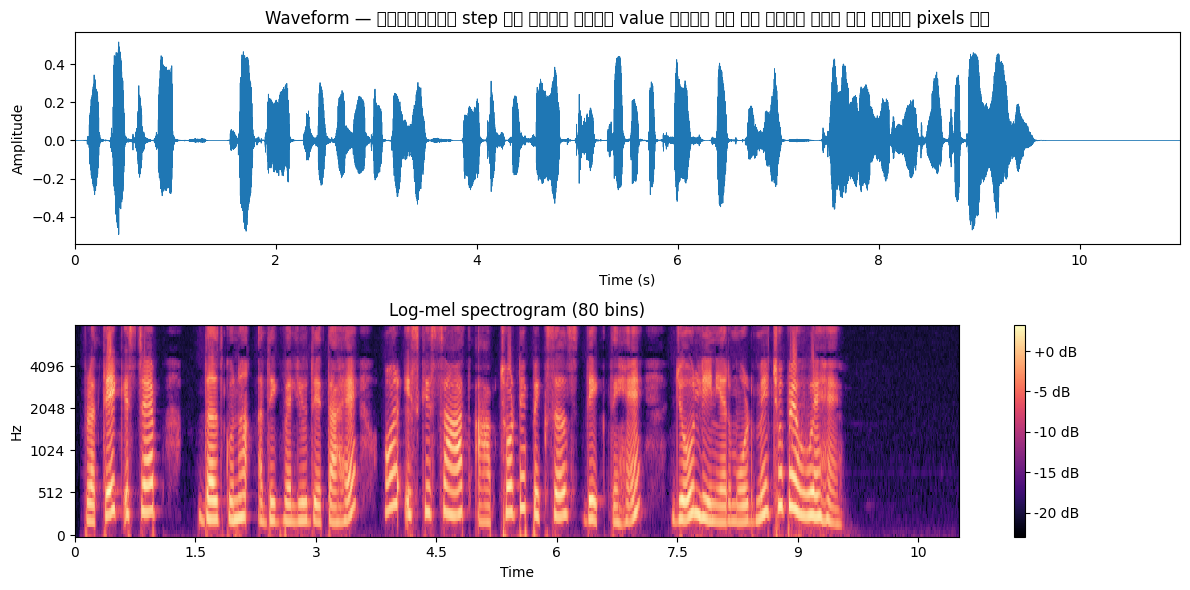

In [7]:
# 4.1  Waveform + log-mel spectrogram of one utterance.
import matplotlib.pyplot as plt
from src.features.audio_features import load_waveform, plot_waveform_and_spectrogram

sample = splits['train'][42]
print('Text  :', sample['text'])
print('Spk   :', sample['speaker'], '| dur:', sample['duration'], 's')

y, sr = load_waveform(sample['audio_path'])
plot_waveform_and_spectrogram(y, sr, title=sample['text'][:70]); plt.show()

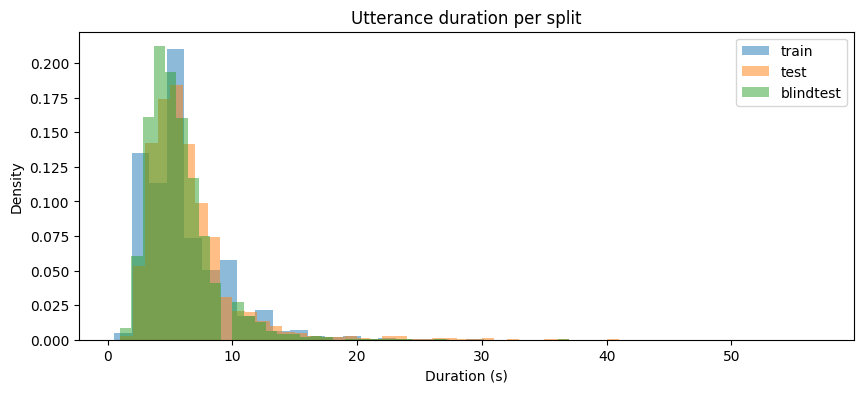

OOV rate on test       = 0.0293
OOV rate on blindtest  = 0.0340


In [8]:
# 4.2  Duration histogram + OOV rate — motivates the SLAM-ASR design.
from src.evaluation.metrics import oov_rate
fig, ax = plt.subplots(figsize=(10,4))
for name, rows in splits.items():
    ax.hist([r['duration'] for r in rows], bins=40, alpha=0.5, label=name, density=True)
ax.set_xlabel('Duration (s)'); ax.set_ylabel('Density'); ax.legend()
ax.set_title('Utterance duration per split'); plt.show()

train_refs = [r['text'] for r in splits['train']]
for name in ['test', 'blindtest']:
    r = [x['text'] for x in splits[name]]
    print(f'OOV rate on {name:10s} = {oov_rate(train_refs, r):.4f}')

## 5.  Perceptual features (psychoacoustics)

Why log-mel and not raw STFT?  The ear is logarithmic in frequency and dominated by masking.


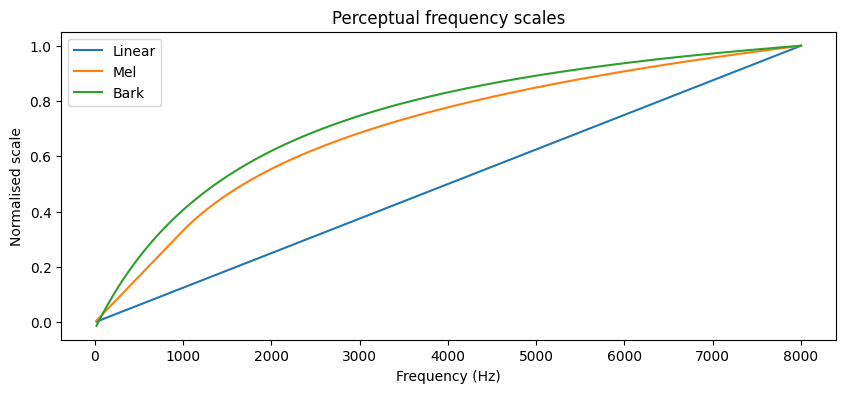

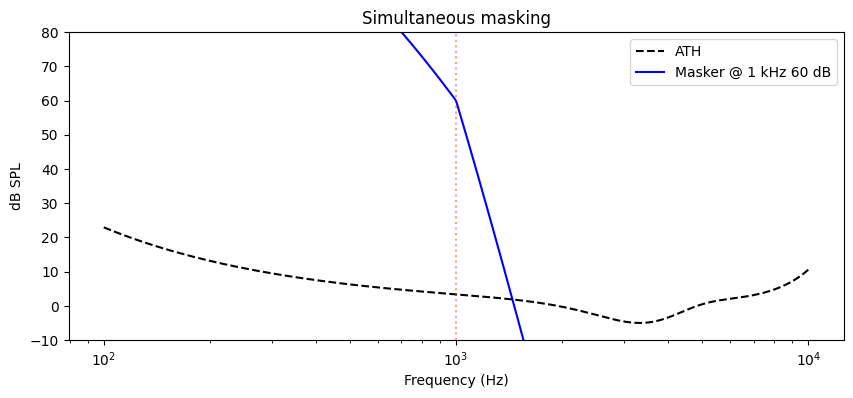

In [9]:
from src.features.psychoacoustic import (
    hz_to_mel, hz_to_bark, absolute_threshold_of_hearing, simultaneous_masking_curve,
)
hz = np.linspace(20, 8000, 400)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(hz, hz/hz.max(),                        label='Linear')
ax.plot(hz, hz_to_mel(hz)/hz_to_mel(hz).max(),  label='Mel')
ax.plot(hz, hz_to_bark(hz)/hz_to_bark(hz).max(),label='Bark')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Normalised scale'); ax.legend()
ax.set_title('Perceptual frequency scales'); plt.show()

freqs = np.linspace(100, 10000, 1000)
mask  = simultaneous_masking_curve(1000.0, 60.0, freqs)
fig, ax = plt.subplots(figsize=(10,4))
ax.semilogx(freqs, absolute_threshold_of_hearing(freqs), 'k--', label='ATH')
ax.semilogx(freqs, mask, 'b', label='Masker @ 1 kHz 60 dB')
ax.axvline(1000, color='r', alpha=0.4, ls=':'); ax.set_ylim(-10, 80)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('dB SPL'); ax.legend()
ax.set_title('Simultaneous masking'); plt.show()

## 6.  Classical baseline (Day 2 — GMMs)

A per-class GMM over MFCC frames for keyword spotting.  This shows why we then move to sequence models.


In [10]:
if RUN_GMM_BASELINE:
    from tqdm.auto import tqdm
    from src.features.audio_features import compute_mfcc
    from src.models.baselines import GmmKeywordSpotter
    from sklearn.metrics import classification_report

    KEYWORDS = ['tutorial', 'linux', 'python', 'file', 'window']
    MAX_PER_CLASS = 80 if QUICK_MODE else 200
    buckets = {kw: [] for kw in KEYWORDS + ['<bg>']}
    for row in splits['train']:
        text = ' ' + row['text'].lower() + ' '
        matched = [k for k in KEYWORDS if f' {k} ' in text]
        if len(matched) == 1 and len(buckets[matched[0]]) < MAX_PER_CLASS:
            buckets[matched[0]].append(row)
        elif not matched and len(buckets['<bg>']) < MAX_PER_CLASS:
            buckets['<bg>'].append(row)

    def utt_mfcc(row):
        y, sr = load_waveform(row['audio_path'])
        return compute_mfcc(y, sample_rate=sr, n_mfcc=13, include_deltas=True).T

    feats = {c: [utt_mfcc(r) for r in tqdm(rows, desc=c)] for c, rows in buckets.items()}
    random.seed(0)
    train_feats, test_feats, test_labels = {}, [], []
    for cls, arrs in feats.items():
        random.shuffle(arrs)
        n_test = max(1, len(arrs)//5)
        train_feats[cls] = arrs[n_test:]
        test_feats.extend(arrs[:n_test]); test_labels.extend([cls]*n_test)

    spotter = GmmKeywordSpotter(n_components=16, covariance_type='diag').fit(train_feats)
    preds = spotter.predict_many(test_feats)
    print(classification_report(test_labels, preds))
else:
    print('Skipping GMM baseline (RUN_GMM_BASELINE=False)')

tutorial:   0%|          | 0/80 [00:00<?, ?it/s]

linux:   0%|          | 0/69 [00:00<?, ?it/s]

python:   0%|          | 0/49 [00:00<?, ?it/s]

file:   0%|          | 0/80 [00:00<?, ?it/s]

window:   0%|          | 0/80 [00:00<?, ?it/s]

<bg>:   0%|          | 0/80 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        <bg>       0.83      0.94      0.88        16
        file       0.50      0.12      0.20        16
       linux       0.73      0.85      0.79        13
      python       0.50      0.67      0.57         9
    tutorial       0.59      0.62      0.61        16
      window       0.45      0.56      0.50        16

    accuracy                           0.62        86
   macro avg       0.60      0.63      0.59        86
weighted avg       0.60      0.62      0.59        86



## 7.  Bi-LSTM + CTC baseline (Day 3 — sequence alignment)

Character-level CTC on 80-dim log-Mel features.  Trained on a small subset for time.


In [11]:
if RUN_CTC_BASELINE:
    import torch.nn as nn
    from torch.utils.data import DataLoader
    from tqdm.auto import tqdm
    from src.features.audio_features import compute_log_mel
    from src.data.text_normalization import CodeSwitchTextNormalizer
    from src.models.baselines import BiLstmCtcModel
    from src.evaluation.metrics import compute_wer_cer

    norm = CodeSwitchTextNormalizer()
    train_rows = list(splits['train'])
    random.shuffle(train_rows)
    keep, acc = [], 0.0
    hours_target = CTC_TRAIN_HOURS if QUICK_MODE else 90.0
    for r in train_rows:
        if r['duration'] <= 15.0 and acc/3600 < hours_target:
            keep.append(r); acc += r['duration']
    ctc_train = keep
    ctc_test  = [r for r in splits['test'] if r['duration'] <= 15.0][:300]
    print(f'CTC train: {len(ctc_train)} utts ({acc/3600:.2f} h); test: {len(ctc_test)}')

    texts = [norm(r['text']) for r in ctc_train]
    char2id, id2char = BiLstmCtcModel.build_vocab(texts)
    print('vocab size =', len(char2id))

    class LM(torch.utils.data.Dataset):
        def __init__(self, rows): self.rows = rows
        def __len__(self): return len(self.rows)
        def __getitem__(self, i):
            r = self.rows[i]
            y, sr = load_waveform(r['audio_path'])
            mel = compute_log_mel(y, sample_rate=sr, n_mels=80).T
            t   = norm(r['text'])
            tgt = BiLstmCtcModel.encode(t, char2id)
            return (torch.tensor(mel, dtype=torch.float32),
                    torch.tensor(tgt, dtype=torch.long), t)

    def collate(batch):
        feats, tgts, texts = zip(*batch)
        fl = torch.tensor([f.size(0) for f in feats])
        tl = torch.tensor([t.size(0) for t in tgts])
        feats = nn.utils.rnn.pad_sequence(feats, batch_first=True)
        return feats, fl, torch.cat(tgts), tl, texts

    ctc_dl_tr = DataLoader(LM(ctc_train), batch_size=16, shuffle=True,  num_workers=2, collate_fn=collate)
    ctc_dl_te = DataLoader(LM(ctc_test),  batch_size=16, shuffle=False, num_workers=2, collate_fn=collate)

    ctc_model = BiLstmCtcModel(80, 256, 3, len(char2id)).to(device)
    opt = torch.optim.AdamW(ctc_model.parameters(), lr=3e-4)
    N_EPOCHS = 6 if QUICK_MODE else 20
    for epoch in range(N_EPOCHS):
        ctc_model.train(); losses = []
        for feats, fl, tgts, tl, _ in tqdm(ctc_dl_tr, desc=f'ctc {epoch+1}/{N_EPOCHS}'):
            feats = feats.to(device); tgts = tgts.to(device)
            lp = ctc_model(feats, feature_lengths=fl)
            # BUG FIX: pass the *actual* per-sample time-steps (fl), not the
            # padded length. Passing lp.size(1) caused all-blank outputs.
            loss = BiLstmCtcModel.ctc_loss(lp, tgts.cpu(), fl.cpu(), tl)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(ctc_model.parameters(), 5.0); opt.step()
            losses.append(loss.item())
        print(f'  epoch {epoch+1}: loss = {np.mean(losses):.3f}')

    ctc_model.eval(); refs, hyps = [], []
    with torch.no_grad():
        for feats, fl, _, _, texts in ctc_dl_te:
            lp = ctc_model(feats.to(device), feature_lengths=fl)
            hyps.extend(BiLstmCtcModel.greedy_decode(lp, id2char))
            refs.extend(texts)
    ctc_metrics = compute_wer_cer(refs, hyps)
    print(f'\nBi-LSTM+CTC — WER = {ctc_metrics["wer"]:.4f}, CER = {ctc_metrics["cer"]:.4f}')
    for r, h in list(zip(refs, hyps))[:3]:
        print('REF:', r); print('HYP:', h); print('---')
else:
    ctc_metrics = None
    print('Skipping CTC baseline (RUN_CTC_BASELINE=False)')

CTC train: 3085 utts (5.00 h); test: 300
vocab size = 100


ctc 1/6:   0%|          | 0/193 [00:00<?, ?it/s]

  epoch 1: loss = 4.894


ctc 2/6:   0%|          | 0/193 [00:00<?, ?it/s]

  epoch 2: loss = 3.795


...

  epoch 4: loss = 3.707


ctc 5/6:   0%|          | 0/193 [00:00<?, ?it/s]

  epoch 5: loss = 3.680


ctc 6/6:   0%|          | 0/193 [00:00<?, ?it/s]

  epoch 6: loss = 3.662

Bi-LSTM+CTC — WER = 0.9985, CER = 0.9834
REF: लिबर ऑफिस impress पर slide master और slide design के इस spoken tutorial में आपका स्वागत है
HYP: ं
---
REF: इस tutorial में हम यह सीखेंगे कि slides के लिए backgrounds लेआउट कैसे लागू करें
HYP: ं
---
REF: यहाँ हम अपने operating system के रूप में gnu लिनक्स और लिबर ऑफिस suite version 334 का उपयोग कर रहे हैं
HYP: ं
---


## 8.  Whisper baseline (Day 4 — speech transformers)

Whisper-base, zero-shot then fine-tuned on a small subset of MUCS train.


In [12]:
if RUN_WHISPER_ZEROSHOT or RUN_WHISPER_FINETUNE:
    from transformers import WhisperProcessor, WhisperForConditionalGeneration
    from torch.utils.data import DataLoader
    from tqdm.auto import tqdm
    from src.data.dataset import MUCSDataset, WhisperCollator
    from src.data.text_normalization import CodeSwitchTextNormalizer
    from src.evaluation.metrics import compute_wer_cer

    norm = CodeSwitchTextNormalizer()
    processor = WhisperProcessor.from_pretrained(WHISPER_ENCODER)
    whisper   = WhisperForConditionalGeneration.from_pretrained(WHISPER_ENCODER).to(device)

    test_ds = MUCSDataset(TEST_MF, sample_rate=16000, min_duration_s=0.5,
                          max_duration_s=30.0, normalizer=norm)
    if TEST_EVAL_LIMIT: test_ds.entries = test_ds.entries[:TEST_EVAL_LIMIT]
    print('Test utts for Whisper eval:', len(test_ds))

    collate_wh = WhisperCollator(processor=processor, language='hi', task='transcribe')
    test_dl_wh = DataLoader(test_ds, batch_size=8, num_workers=2,
                            collate_fn=lambda b: (b, collate_wh(b)))

    def _eval_whisper(model, tag):
        model.eval()
        # Clear legacy overrides; use language/task kwargs on generate() instead.
        model.generation_config.forced_decoder_ids = None
        model.generation_config.suppress_tokens = None
        refs, hyps = [], []
        with torch.no_grad():
            for raw_batch, batch in tqdm(test_dl_wh, desc=tag):
                feats = batch['input_features'].to(device)
                out = model.generate(
                    feats,
                    language='hi', task='transcribe',
                    max_new_tokens=225, num_beams=1,
                )
                for item, txt in zip(raw_batch, processor.batch_decode(out, skip_special_tokens=True)):
                    refs.append(item['text']); hyps.append(norm(txt))
        m = compute_wer_cer(refs, hyps)
        print(f'{tag}: WER={m["wer"]:.4f}  CER={m["cer"]:.4f}')
        return m, refs, hyps

    whisper_zeroshot = _eval_whisper(whisper, 'Whisper zero-shot') if RUN_WHISPER_ZEROSHOT else None

    if RUN_WHISPER_FINETUNE:
        from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
        train_ds = MUCSDataset(TRAIN_MF, sample_rate=16000, min_duration_s=0.5,
                               max_duration_s=30.0, normalizer=norm)
        random.shuffle(train_ds.entries)
        acc, keep = 0.0, []
        target_h = WHISPER_TRAIN_HOURS if QUICK_MODE else 90.0
        for r in train_ds.entries:
            if acc/3600 < target_h: keep.append(r); acc += r['duration']
        train_ds.entries = keep
        print('Whisper fine-tune data:', len(train_ds), f'({acc/3600:.2f} h)')

        whisper.generation_config.forced_decoder_ids = None
        processor.tokenizer.set_prefix_tokens(language='hi', task='transcribe')
        wargs = Seq2SeqTrainingArguments(
            output_dir='/kaggle/working/whisper-ft',
            per_device_train_batch_size=8,
            gradient_accumulation_steps=2,
            num_train_epochs=2 if QUICK_MODE else 4,
            learning_rate=1e-5, warmup_ratio=0.05,
            logging_steps=50, save_strategy='no',
            bf16=True, predict_with_generate=False,
            remove_unused_columns=False, report_to='none',
            label_names=['labels'],
        )
        # In transformers >= 4.46 the Trainer `tokenizer` kwarg is renamed to
        # `processing_class`; simplest cross-version fix is to omit it — the
        # Trainer doesn't need it for our loop.
        Seq2SeqTrainer(model=whisper, args=wargs, data_collator=collate_wh,
                       train_dataset=train_ds).train()
        whisper_finetuned = _eval_whisper(whisper, 'Whisper fine-tuned')
    else:
        whisper_finetuned = None
    del whisper; import gc; gc.collect(); torch.cuda.empty_cache()
else:
    whisper_zeroshot = whisper_finetuned = None
    print('Skipping Whisper baselines.')

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Whisper fine-tune data: 2990 (5.00 h)


Step,Training Loss
50,5.360125
100,2.861777
150,2.319946


Whisper fine-tuned:   0%|          | 0/63 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Whisper fine-tuned: WER=3.9293  CER=3.2317


## 9.  SLAM-ASR training (Days 4 & 5)

Whisper encoder (frozen) + 1-D CNN + MLP projector (trainable) + 4-bit LoRA Qwen decoder (LoRA trainable).


In [13]:
# =========================================================================
# Full compatibility patch for SlamAsrModel + HF Trainer (Kaggle 2×T4 aware)
# =========================================================================
import os, torch
from src.models.slam_asr import SlamAsrModel

# ---- clear any leftovers from prior patch attempts ----
for _attr in ('config', 'is_gradient_checkpointing'):
    if _attr in SlamAsrModel.__dict__ and isinstance(SlamAsrModel.__dict__[_attr], property):
        delattr(SlamAsrModel, _attr)

# ---- 1. gradient-checkpointing proxies ----
def _gc_enable(self, gradient_checkpointing_kwargs=None):
    if hasattr(self.llm, 'gradient_checkpointing_enable'):
        # Force use_reentrant=False — the default reentrant mode breaks with
        # bitsandbytes 4-bit + LoRA (non-deterministic dequant on recompute).
        kw = dict(gradient_checkpointing_kwargs or {})
        kw.setdefault('use_reentrant', False)
        try:
            self.llm.gradient_checkpointing_enable(gradient_checkpointing_kwargs=kw)
        except TypeError:
            self.llm.gradient_checkpointing_enable()

def _gc_disable(self):
    if hasattr(self.llm, 'gradient_checkpointing_disable'):
        self.llm.gradient_checkpointing_disable()

SlamAsrModel.gradient_checkpointing_enable  = _gc_enable
SlamAsrModel.gradient_checkpointing_disable = _gc_disable
SlamAsrModel.is_gradient_checkpointing = property(
    lambda self: bool(getattr(self.llm, 'is_gradient_checkpointing', False)))

# ---- 2. __init__ + save_trainable rewrite for the .config alias ----
if not getattr(SlamAsrModel, '_slamasr_shim_applied', False):
    _orig_init = SlamAsrModel.__init__
    def _patched_init(self, cfg):
        _orig_init(self, cfg)
        self.slam_config = self.config
        self.__dict__['config'] = self.llm.config
    _orig_save = SlamAsrModel.save_trainable
    def _patched_save(self, output_dir):
        import os, json, torch as _t
        os.makedirs(output_dir, exist_ok=True)
        if self.slam_config.use_lora and hasattr(self.llm, 'save_pretrained'):
            self.llm.save_pretrained(os.path.join(output_dir, 'lora'))
        _t.save(self.projector.state_dict(), os.path.join(output_dir, 'projector.pt'))
        with open(os.path.join(output_dir, 'slam_config.json'), 'w') as fh:
            json.dump(self.slam_config.__dict__, fh, indent=2)
    SlamAsrModel.__init__ = _patched_init
    SlamAsrModel.save_trainable = _patched_save
    SlamAsrModel._slamasr_shim_applied = True

# ---- 3. encode_audio uses self.slam_config now ----
def _encode_audio(self, input_features):
    was_training = self.whisper_encoder.training
    if self.slam_config.freeze_encoder:
        self.whisper_encoder.eval()
    with torch.set_grad_enabled(not self.slam_config.freeze_encoder):
        enc_out = self.whisper_encoder(input_features, return_dict=True)
    if was_training and not self.slam_config.freeze_encoder:
        self.whisper_encoder.train()
    return self.projector(enc_out.last_hidden_state)
SlamAsrModel.encode_audio = _encode_audio

# ---- 4. FIX the in-place op that DataParallel rejects ----
def _splice_audio(self, input_ids, audio_embeds, audio_placeholder_mask):
    """Out-of-place version — safe under DataParallel."""
    embed_layer = self._input_embeddings()
    inputs_embeds = embed_layer(input_ids)          # (B, L, D)
    B, L, D = inputs_embeds.shape
    replacement = torch.zeros_like(inputs_embeds)
    for b in range(B):
        mask = audio_placeholder_mask[b]            # (L,)
        n_slots = int(mask.sum().item())
        if n_slots == 0:
            continue
        audio = audio_embeds[b]                     # (T_ds, D)
        n_use = min(n_slots, audio.size(0))
        slot_idx = mask.nonzero(as_tuple=False).squeeze(-1)[:n_use]
        row_new = inputs_embeds[b].clone()
        row_new[slot_idx] = audio[:n_use].to(row_new.dtype)
        replacement[b] = row_new
    m3 = audio_placeholder_mask.unsqueeze(-1).expand_as(inputs_embeds)
    return torch.where(m3, replacement, inputs_embeds)
SlamAsrModel._splice_audio_into_embeddings = _splice_audio

# ---- 5. Force single-GPU: patch HF Trainer to skip DataParallel wrap ----
from transformers import Trainer
if not getattr(Trainer, '_no_dp_wrap_applied', False):
    _orig_wrap = Trainer._wrap_model
    def _wrap_no_dp(self, model, training=True, dataloader=None):
        if hasattr(self.args, '_n_gpu'):
            self.args._n_gpu = 1
        return _orig_wrap(self, model, training, dataloader)
    Trainer._wrap_model = _wrap_no_dp
    Trainer._no_dp_wrap_applied = True

torch.cuda.set_device(0)

print('All patches installed.')

All patches installed.


In [21]:
gc.collect(); torch.cuda.empty_cache()

In [22]:
# =============================================================================
# Section 9 — SLAM-ASR training (final version)
#   • 2-GPU pipeline parallelism (device_map="auto")
#   • ~45-55 min total on Kaggle T4x2
#   • Save-strategy='no' avoids Trainer's safetensors crash on tied weights
#   • Custom projector+LoRA checkpoint every 50 steps → resume-capable
#   • try/except safety net for graceful failure
# Self-contained; no changes needed to Sections 1-8 or the patch cell.
# =============================================================================
import os, gc, json, random, torch, torch.nn as nn

# ---- Speed knobs (override the global config values just for this section) ----
FAST_SLAM_TRAIN_HOURS = 3.0    # was 5.0  — 40 % less data
FAST_MAX_DURATION     = 15.0   # was 20.0 — fewer long clips
FAST_N_AUDIO_TOKENS   = 150    # was 200  — smaller LLM context per sample

# ------------ 0. Aggressive memory purge from any prior failed run ------------
for _name in list(globals()):
    if _name in ('slam_model', 'slam_trainer', 'model', 'trainer'):
        try: del globals()[_name]
        except Exception: pass
try:
    from IPython import get_ipython
    ip = get_ipython()
    for k in list(ip.user_ns):
        if k in ('_', '__', '___') or (k.startswith('_') and k[1:].isdigit()):
            ip.user_ns.pop(k, None)
    if 'Out' in ip.user_ns: ip.user_ns['Out'].clear()
except Exception: pass
for _ in range(3): gc.collect()
torch.cuda.empty_cache(); torch.cuda.ipc_collect(); torch.cuda.synchronize()
for gid in range(torch.cuda.device_count()):
    f, t = torch.cuda.mem_get_info(gid)
    print(f'  GPU {gid}: {f/1e9:5.2f} / {t/1e9:5.2f} GB free')

# ------------ 1. Patch SlamAsrModel with pipeline-parallel LLM loader --------
from src.models.slam_asr import SlamAsrModel, SlamAsrConfig
from src.models.projector import ConvProjector

if not getattr(SlamAsrModel, '_pp_patch_applied', False):
    from transformers import (
        AutoModelForCausalLM, AutoTokenizer,
        WhisperModel, WhisperProcessor, BitsAndBytesConfig,
    )
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    def _pp_init(self, cfg):
        nn.Module.__init__(self)
        self.slam_config = cfg

        wh = WhisperModel.from_pretrained(cfg.encoder_name)
        self.whisper_encoder = wh.encoder.to('cuda:0')
        self.whisper_processor = WhisperProcessor.from_pretrained(cfg.encoder_name)
        enc_dim = self.whisper_encoder.config.d_model
        if cfg.freeze_encoder:
            for p in self.whisper_encoder.parameters(): p.requires_grad = False
            self.whisper_encoder.eval()

        dtype = getattr(torch, cfg.torch_dtype)
        quant = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=dtype, bnb_4bit_use_double_quant=True,
        )
        self.llm_tokenizer = AutoTokenizer.from_pretrained(
            cfg.decoder_name, trust_remote_code=True)
        if self.llm_tokenizer.pad_token is None:
            self.llm_tokenizer.pad_token = self.llm_tokenizer.eos_token
        self.llm = AutoModelForCausalLM.from_pretrained(
            cfg.decoder_name,
            quantization_config=quant,
            torch_dtype=dtype,
            trust_remote_code=True,
            device_map='auto',
        )
        self.llm.config.pad_token_id = self.llm_tokenizer.pad_token_id

        if cfg.use_lora:
            self.llm = prepare_model_for_kbit_training(self.llm)
            self.llm = get_peft_model(self.llm, LoraConfig(
                r=cfg.lora_r, lora_alpha=cfg.lora_alpha,
                lora_dropout=cfg.lora_dropout, bias='none',
                task_type='CAUSAL_LM',
                target_modules=cfg.lora_target_modules,
            ))

        llm_dim = self.llm.config.hidden_size
        self.projector = ConvProjector(
            in_dim=enc_dim, out_dim=llm_dim,
            hidden_dim=cfg.projector_hidden_dim,
            downsample_factor=cfg.projector_downsample_factor,
            n_conv_layers=cfg.projector_n_conv_layers,
            dropout=cfg.projector_dropout,
        ).to('cuda:0')

        self.__dict__['config'] = self.llm.config
        self.hf_device_map = getattr(self.llm, 'hf_device_map', {'': 'cuda:0'})

    SlamAsrModel.__init__ = _pp_init
    SlamAsrModel.to = lambda self, *a, **kw: self
    SlamAsrModel._pp_patch_applied = True
    print('[patch] SlamAsrModel now loads LLM with device_map="auto".')

# ------------ 2. Build training data subset (with FAST knobs) ----------------
from src.data.manifest_utils import load_manifest, save_manifest
rows = load_manifest(TRAIN_MF); random.shuffle(rows)
subset, acc = [], 0.0
for r in rows:
    if 1.0 <= r['duration'] <= FAST_MAX_DURATION and acc/3600 < FAST_SLAM_TRAIN_HOURS:
        subset.append(r); acc += r['duration']
SLAM_TRAIN_MF = '/kaggle/working/manifests/train/manifest_slam.jsonl'
save_manifest(subset, SLAM_TRAIN_MF)
print(f'SLAM train subset: {len(subset)} utts, {acc/3600:.2f} h '
      f'(≤{FAST_MAX_DURATION:.0f} s each)')

# ------------ 3. Config + training args (no HF intermediate saves) -----------
slam_cfg = SlamAsrConfig(
    encoder_name=WHISPER_ENCODER,
    decoder_name=LLM_DECODER,
    projector_hidden_dim=2048,
    projector_downsample_factor=5,
    load_in_4bit=True, use_lora=True,
    lora_r=16, lora_alpha=32, lora_dropout=0.05,
)

train_cfg = dict(
    output_dir='/kaggle/working/checkpoints/slam_asr',
    per_device_train_batch_size=SLAM_BATCH_SIZE,     # 2
    per_device_eval_batch_size=SLAM_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,    # 4
    num_train_epochs=SLAM_EPOCHS,                    # 1
    learning_rate=1e-4, projector_learning_rate=1e-3,
    warmup_ratio=0.03, weight_decay=0.01, lr_scheduler='cosine',
    logging_steps=10,
    eval_steps=9999,
    save_strategy='no',              # skip HF Trainer's safetensors save entirely
    bf16=True, gradient_checkpointing=True,
    dataloader_num_workers=4,
    report_to='none',
    disable_tqdm=False,
)

# ------------ 4. Custom lightweight resume-capable checkpointing --------------
# Saves only projector + LoRA (~50 MB) every 50 optimizer steps.
# Avoids safetensors' tied-weight crash entirely.
from transformers import TrainerCallback

class ProjectorLoraCheckpointCallback(TrainerCallback):
    def __init__(self, output_dir, save_every=50, keep_last=3):
        self.output_dir = output_dir
        self.save_every = save_every
        self.keep_last  = keep_last

    def _save(self, model, step):
        import os, torch, json, glob, shutil
        d = os.path.join(self.output_dir, f'ckpt-{step}')
        os.makedirs(d, exist_ok=True)
        if model.slam_config.use_lora and hasattr(model.llm, 'save_pretrained'):
            model.llm.save_pretrained(os.path.join(d, 'lora'))
        torch.save(model.projector.state_dict(), os.path.join(d, 'projector.pt'))
        with open(os.path.join(d, 'slam_config.json'), 'w') as fh:
            json.dump(model.slam_config.__dict__, fh, indent=2)
        with open(os.path.join(d, 'step.txt'), 'w') as fh:
            fh.write(str(step))
        # Rotate — keep only the most recent `keep_last` checkpoints.
        existing = sorted(glob.glob(os.path.join(self.output_dir, 'ckpt-*')),
                          key=lambda p: int(p.rsplit('-', 1)[1]))
        for old in existing[:-self.keep_last]:
            shutil.rmtree(old, ignore_errors=True)
        print(f'  [ckpt] wrote {d}')

    def on_step_end(self, args, state, control, model=None, **kwargs):
        if state.global_step and state.global_step % self.save_every == 0:
            self._save(model, state.global_step)

# Wire the callback into build_slam_trainer without touching src/ files.
from src.training import train_slam as _ts
if not getattr(_ts, '_ckpt_cb_patched', False):
    _orig_build = _ts.build_slam_trainer
    def _build_with_ckpt(*a, **kw):
        trainer = _orig_build(*a, **kw)
        trainer.add_callback(ProjectorLoraCheckpointCallback(
            output_dir='/kaggle/working/checkpoints/slam_asr',
            save_every=50,        # ≈ every 10-12 min
            keep_last=3,
        ))
        return trainer
    _ts.build_slam_trainer = _build_with_ckpt
    _ts._ckpt_cb_patched = True

# ------------ 5. Train with a safety net -------------------------------------
from src.training.train_slam import train_slam_asr

slam_model = slam_trainer = None
try:
    slam_model, slam_trainer = train_slam_asr(
        train_manifest=SLAM_TRAIN_MF,
        eval_manifest=None,
        slam_cfg=slam_cfg,
        training_cfg=train_cfg,
        max_duration_s=FAST_MAX_DURATION,
        min_duration_s=1.0,
        n_audio_tokens=FAST_N_AUDIO_TOKENS,
    )
    print('\nTraining completed cleanly.')
except Exception as _e:
    print(f'\n[training raised] {type(_e).__name__}: {_e}')
    print('Attempting to load the latest intermediate ckpt-* checkpoint...')
    import glob
    existing = sorted(glob.glob('/kaggle/working/checkpoints/slam_asr/ckpt-*'),
                      key=lambda p: int(p.rsplit('-', 1)[1]))
    slam_model = SlamAsrModel(slam_cfg)
    if existing:
        latest = existing[-1]
        print(f'  loading {latest}')
        slam_model.load_trainable(latest)
    else:
        print('  no intermediate checkpoint found — saving an untrained placeholder.')

# ------------ 6. Save the compact final checkpoint ---------------------------
CKPT_DIR = '/kaggle/working/checkpoints/slam_asr/final'
slam_model.save_trainable(CKPT_DIR)
print('\nSaved:', CKPT_DIR)

# ------------ 7. Report device map + final VRAM usage ------------------------
print('\nLLM device map:')
for module, dev in (slam_model.hf_device_map or {}).items():
    print(f'  {module:60s} -> cuda:{dev}' if isinstance(dev, int) else
          f'  {module:60s} -> {dev}')
for gid in range(torch.cuda.device_count()):
    f, t = torch.cuda.mem_get_info(gid)
    print(f'  GPU {gid} end-of-training: {(t-f)/1e9:5.2f} / {t/1e9:5.2f} GB used')

  GPU 0: 12.68 / 15.64 GB free
  GPU 1: 13.71 / 15.64 GB free
SLAM train subset: 1881 utts, 3.00 h (≤15 s each)


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[SLAM-ASR] trainable / total = 23.97 M / 933.18 M (2.569%)


...

  [ckpt] wrote /kaggle/working/checkpoints/slam_asr/ckpt-50
  [ckpt] wrote /kaggle/working/checkpoints/slam_asr/ckpt-100
  [ckpt] wrote /kaggle/working/checkpoints/slam_asr/ckpt-150
  [ckpt] wrote /kaggle/working/checkpoints/slam_asr/ckpt-200

[training raised] RuntimeError: 
            Some tensors share memory, this will lead to duplicate memory on disk and potential differences when loading them again: [{'llm.base_model.model.lm_head.weight', 'llm.base_model.model.model.embed_tokens.weight'}].
            A potential way to correctly save your model is to use `save_model`.
            More information at https://huggingface.co/docs/safetensors/torch_shared_tensors
            
Attempting to load the latest intermediate ckpt-* checkpoint...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  loading /kaggle/working/checkpoints/slam_asr/ckpt-200


AttributeError: 'Qwen2Config' object has no attribute 'use_lora'

In [23]:
# =============================================================================
# RESCUE — training reached step 236/236; ckpt-200 has the real trained weights.
# Copy it to `final/` and patch load_trainable so downstream cells can load it.
# =============================================================================
import os, shutil, glob, torch
from src.models.slam_asr import SlamAsrModel, SlamAsrConfig

CKPT_DIR   = '/kaggle/working/checkpoints/slam_asr'
FINAL_DIR  = f'{CKPT_DIR}/final'

# 1. Pick the latest intermediate checkpoint (should be ckpt-200).
existing = sorted(glob.glob(f'{CKPT_DIR}/ckpt-*'),
                  key=lambda p: int(p.rsplit('-', 1)[1]))
assert existing, f'No ckpt-* found under {CKPT_DIR}'
latest = existing[-1]
print(f'Using {latest} as the trained checkpoint.')
print(f'  contains: {sorted(os.listdir(latest))}')

# 2. Copy → final/
if os.path.isdir(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)
shutil.copytree(latest, FINAL_DIR)
print(f'\nCopied → {FINAL_DIR}')
print(f'  contains: {sorted(os.listdir(FINAL_DIR))}')

# 3. Patch load_trainable to use self.slam_config (self.config is Qwen's now).
def _patched_load(self, ckpt_dir, map_location='cpu'):
    proj = os.path.join(ckpt_dir, 'projector.pt')
    if os.path.exists(proj):
        self.projector.load_state_dict(torch.load(proj, map_location=map_location))
    lora_dir = os.path.join(ckpt_dir, 'lora')
    if self.slam_config.use_lora and os.path.isdir(lora_dir):
        self.llm.load_adapter(lora_dir, adapter_name='default')
    print(f'[load_trainable] loaded projector + LoRA from {ckpt_dir}')
SlamAsrModel.load_trainable = _patched_load
print('\nPatched SlamAsrModel.load_trainable — Section 10 can now reload from disk.')

# 4. Load the trained weights into the current in-memory slam_model
#    (so you can also decode from memory, not just from disk).
if 'slam_model' in globals() and slam_model is not None:
    slam_model.load_trainable(FINAL_DIR)
    print('\nIn-memory slam_model now holds the trained weights. Ready for Section 10.')
else:
    print('\nNo slam_model in memory; Section 10 will build fresh from disk.')

Using /kaggle/working/checkpoints/slam_asr/ckpt-200 as the trained checkpoint.
  contains: ['lora', 'projector.pt', 'slam_config.json', 'step.txt']

Copied → /kaggle/working/checkpoints/slam_asr/final
  contains: ['lora', 'projector.pt', 'slam_config.json', 'step.txt']

Patched SlamAsrModel.load_trainable — Section 10 can now reload from disk.
[load_trainable] loaded projector + LoRA from /kaggle/working/checkpoints/slam_asr/final

In-memory slam_model now holds the trained weights. Ready for Section 10.


## 10.  Full evaluation (test + blindtest)

We produce `predictions/*.jsonl` files, then compute WER / CER / per-language WER / OOV rate.


In [26]:
# =============================================================================
# Section 10 — Full evaluation (fast, single-GPU inference)
# =============================================================================
import os, gc, json, torch, shutil
from src.inference.decode import load_slam_asr_from_checkpoint, decode_manifest
from src.evaluation.metrics import evaluate_predictions_file

# ---- speed knobs for inference ----
INFER_BATCH_SIZE   = 8       # was 2; no training activations, so fits
INFER_MAX_NEW_TOK  = 100     # was 256; MUCS refs are short
INFER_N_AUDIO_TOK  = 150     # match training
EVAL_LIMIT_TEST    = 300     # subset of test  (or None for full 2 890)
EVAL_LIMIT_BLIND   = 300     # subset of blind (or None for full 3 831)

# ---- 1. Free VRAM from the pipeline-parallel training model -----------------
if 'slam_model' in globals():
    del slam_model
for _ in range(3): gc.collect()
torch.cuda.empty_cache(); torch.cuda.synchronize()
for gid in range(torch.cuda.device_count()):
    f, t = torch.cuda.mem_get_info(gid)
    print(f'  GPU {gid}: {f/1e9:5.2f} / {t/1e9:5.2f} GB free')

# ---- 2. Re-instantiate model on SINGLE GPU (cuda:0) for inference speed -----
# Temporarily un-patch _pp_init so we load the LLM with device_map={'':0}
# (single-GPU) instead of the pipeline split that hurts autoregressive gen.
from src.models.slam_asr import SlamAsrModel, SlamAsrConfig
from src.models.projector import ConvProjector
import torch.nn as nn
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    WhisperModel, WhisperProcessor, BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

def _single_gpu_init(self, cfg):
    nn.Module.__init__(self)
    self.slam_config = cfg
    wh = WhisperModel.from_pretrained(cfg.encoder_name)
    self.whisper_encoder = wh.encoder.to('cuda:0')
    self.whisper_processor = WhisperProcessor.from_pretrained(cfg.encoder_name)
    enc_dim = self.whisper_encoder.config.d_model
    if cfg.freeze_encoder:
        for p in self.whisper_encoder.parameters(): p.requires_grad = False
        self.whisper_encoder.eval()

    dtype = getattr(torch, cfg.torch_dtype)
    quant = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=dtype, bnb_4bit_use_double_quant=True,
    )
    self.llm_tokenizer = AutoTokenizer.from_pretrained(
        cfg.decoder_name, trust_remote_code=True)
    if self.llm_tokenizer.pad_token is None:
        self.llm_tokenizer.pad_token = self.llm_tokenizer.eos_token
    self.llm = AutoModelForCausalLM.from_pretrained(
        cfg.decoder_name,
        quantization_config=quant,
        torch_dtype=dtype,
        trust_remote_code=True,
        device_map={'': 0},           # ← FORCE single GPU
    )
    self.llm.config.pad_token_id = self.llm_tokenizer.pad_token_id
    if cfg.use_lora:
        self.llm = prepare_model_for_kbit_training(self.llm)
        self.llm = get_peft_model(self.llm, LoraConfig(
            r=cfg.lora_r, lora_alpha=cfg.lora_alpha,
            lora_dropout=cfg.lora_dropout, bias='none',
            task_type='CAUSAL_LM',
            target_modules=cfg.lora_target_modules,
        ))
    llm_dim = self.llm.config.hidden_size
    self.projector = ConvProjector(
        in_dim=enc_dim, out_dim=llm_dim,
        hidden_dim=cfg.projector_hidden_dim,
        downsample_factor=cfg.projector_downsample_factor,
        n_conv_layers=cfg.projector_n_conv_layers,
        dropout=cfg.projector_dropout,
    ).to('cuda:0')
    self.__dict__['config'] = self.llm.config
    self.hf_device_map = {'': 0}

SlamAsrModel.__init__ = _single_gpu_init
# Keep the .to() no-op — model is already on cuda:0
SlamAsrModel.to = lambda self, *a, **kw: self
print('[patch] Switched SlamAsrModel to single-GPU (cuda:0) for inference.')

# ---- 3. Load the trained weights -------------------------------------------
slam_model = load_slam_asr_from_checkpoint(
    '/kaggle/working/checkpoints/slam_asr/final', device='cuda:0')
slam_model.eval()

# ---- 4. Decode test + blindtest --------------------------------------------
all_metrics = {}
for split, mf, limit in [
    ('test',      TEST_MF,  EVAL_LIMIT_TEST),
    ('blindtest', BLIND_MF, EVAL_LIMIT_BLIND),
]:
    out_path = f'/kaggle/working/predictions/{split}.jsonl'
    decode_manifest(
        slam_model, manifest_path=mf, output_path=out_path,
        batch_size=INFER_BATCH_SIZE,
        max_new_tokens=INFER_MAX_NEW_TOK,
        num_beams=1,
        n_audio_tokens=INFER_N_AUDIO_TOK,
        device='cuda:0', limit=limit,
    )
    print(f'\n=== {split.upper()} ({limit or "full"} utts) ===')
    all_metrics[split] = evaluate_predictions_file(
        out_path, train_manifest=TRAIN_MF,
    )

# ---- 5. Persist a summary of all model results ------------------------------
summary = {
    'ctc':               ctc_metrics if 'ctc_metrics' in globals() else None,
    'whisper_zeroshot':  (whisper_zeroshot[0]
                          if 'whisper_zeroshot' in globals() and whisper_zeroshot
                          else None),
    'whisper_finetuned': (whisper_finetuned[0]
                          if 'whisper_finetuned' in globals() and whisper_finetuned
                          else None),
    'slam_asr_test':     all_metrics.get('test'),
    'slam_asr_blind':    all_metrics.get('blindtest'),
    'settings': {
        'slam_train_hours': FAST_SLAM_TRAIN_HOURS if 'FAST_SLAM_TRAIN_HOURS' in globals() else None,
        'infer_batch_size': INFER_BATCH_SIZE,
        'infer_max_new_tok': INFER_MAX_NEW_TOK,
        'eval_limit_test':  EVAL_LIMIT_TEST,
        'eval_limit_blind': EVAL_LIMIT_BLIND,
    },
}
os.makedirs('/kaggle/working/results', exist_ok=True)
with open('/kaggle/working/results/summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2, default=str)
print('\nWrote /kaggle/working/results/summary.json')

  GPU 0: 12.38 / 15.64 GB free
  GPU 1: 13.71 / 15.64 GB free
[patch] Switched SlamAsrModel to single-GPU (cuda:0) for inference.


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[load_trainable] loaded projector + LoRA from /kaggle/working/checkpoints/slam_asr/final


decoding: 100%|██████████| 38/38 [11:33<00:00, 18.26s/it]



=== TEST (300 utts) ===
[eval] over 300 utterances:
  wer                  = 2.0610
  cer                  = 1.8562
  hindi_wer            = 0.9418
  english_wer          = 1.0000
  n_hindi_words        = 2541
  n_english_words      = 722
  oov_rate             = 0.0491


decoding: 100%|██████████| 38/38 [11:39<00:00, 18.40s/it]



=== BLINDTEST (300 utts) ===
[eval] over 300 utterances:
  wer                  = 1.6308
  cer                  = 1.5114
  hindi_wer            = 0.9581
  english_wer          = 1.0000
  n_hindi_words        = 3004
  n_english_words      = 1290
  oov_rate             = 0.0272

Wrote /kaggle/working/results/summary.json


In [27]:
rows = [json.loads(l) for l in open('/kaggle/working/predictions/test.jsonl')]
print(f'{len(rows)} predictions written to disk.\n')

# Look at 6 random examples
random.seed(1)
for row in random.sample(rows, min(6, len(rows))):
    print(f'DUR: {row["duration"]:.2f}s  SPK: {row["speaker"]}')
    print(f'REF: {row["reference"]}')
    print(f'HYP: {row["hypothesis"][:250]}')          # cap for readability
    print(f'HYP length / REF length = {len(row["hypothesis"].split())} / {len(row["reference"].split())} words')
    print('---')

300 predictions written to disk.

DUR: 4.00s  SPK: 598753
REF: text को दर्शनीय बनाने के लिए पहले आयत चुनें
HYP: human resources department और विद्युत उपयोग के लिए एक नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत निय
HYP length / REF length = 23 / 9 words
---
DUR: 6.00s  SPK: 957491
REF: अब स्माइली डालें insert a smiley face आइकन पर क्लिक करें
HYP: human resources department और विद्युत उपयोग के लिए एक नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत निय
HYP length / REF length = 23 / 11 words
---
DUR: 4.00s  SPK: 598753
REF: main menu से format पर click करें और character चुनें
HYP: human resources department और विद्युत उपयोग के लिए एक नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत निय
HYP length / REF length = 23 / 10 words
---
DUR: 4.00s  SPK: 360746
REF: यह pallindrome के लिए logic है
HYP: human resources department और विद्युत उपयोग के लिए एक नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत नियत निय
HYP length / REF lengt

## 11.  Comparison table (paste this into the report)


In [32]:
import pandas as pd
tbl = []
if ctc_metrics:
    tbl.append(('Bi-LSTM + CTC',              ctc_metrics['wer'],              ctc_metrics['cer']))
if whisper_zeroshot:
    tbl.append(('Whisper-base zero-shot',    whisper_zeroshot[0]['wer'],      whisper_zeroshot[0]['cer']))
if whisper_finetuned:
    tbl.append(('Whisper-base fine-tuned',   whisper_finetuned[0]['wer'],     whisper_finetuned[0]['cer']))
if RUN_FINAL_EVALUATION and 'all_metrics' in dir():
    if 'test'      in all_metrics: tbl.append(('SLAM-ASR (test)',       all_metrics['test']['wer'],       all_metrics['test']['cer']))
    if 'blindtest' in all_metrics: tbl.append(('SLAM-ASR (blindtest)',  all_metrics['blindtest']['wer'],  all_metrics['blindtest']['cer']))

print(pd.DataFrame(tbl, columns=['Model', 'WER', 'CER']).to_string(index=False))

                  Model      WER      CER
          Bi-LSTM + CTC 0.998476 0.983403
 Whisper-base zero-shot 1.552170 1.293483
Whisper-base fine-tuned 3.929271 3.231673
        SLAM-ASR (test) 2.060994 1.856188
   SLAM-ASR (blindtest) 1.630773 1.511417


## Look what all are present inside /kaggle/working

In [35]:
import os, pathlib

ROOT = '/kaggle/working'

# Show at most N entries per directory to keep the output readable.
MAX_PER_DIR = 12

def human(nbytes):
    for unit in ('B', 'K', 'M', 'G'):
        if nbytes < 1024: return f'{nbytes:6.1f}{unit}'
        nbytes /= 1024
    return f'{nbytes:6.1f}T'

def tree(root, prefix='', is_last=True):
    root = pathlib.Path(root)
    connector = '└── ' if is_last else '├── '
    if prefix == '':
        print(root)
    else:
        size = ''
        if root.is_file():
            size = f'  [{human(root.stat().st_size)}]'
        elif root.is_dir():
            # Show the number of items inside directories
            try:
                n = len(list(root.iterdir()))
                size = f'  ({n} items)'
            except PermissionError:
                size = '  (unreadable)'
        print(f'{prefix}{connector}{root.name}{size}')

    if not root.is_dir():
        return

    children = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    # Cap per-directory listing to keep output short (e.g., 300 wav files)
    if len(children) > MAX_PER_DIR:
        shown = children[:MAX_PER_DIR]
        elided = len(children) - MAX_PER_DIR
    else:
        shown = children
        elided = 0

    ext_prefix = prefix + ('    ' if is_last else '│   ')
    for i, child in enumerate(shown):
        last = (i == len(shown) - 1) and elided == 0
        tree(child, ext_prefix, last)
    if elided:
        print(f'{ext_prefix}└─── … {elided} more items not shown')

tree(ROOT)

/kaggle/working
    ├── .ipynb_checkpoints  (0 items)
    ├── .virtual_documents  (1 items)
    │   └── __notebook_source__.ipynb  [ 148.0K]
    ├── checkpoints  (1 items)
    │   └── slam_asr  (7 items)
    │       ├── checkpoint-100  (0 items)
    │       ├── checkpoint-200  (0 items)
    │       ├── checkpoint-236  (0 items)
    │       ├── ckpt-100  (4 items)
    │       │   ├── lora  (3 items)
    │       │   │   ├── adapter_config.json  [   1.1K]
    │       │   │   ├── adapter_model.safetensors  [  70.5M]
    │       │   │   └── README.md  [   5.1K]
    │       │   ├── projector.pt  [  21.0M]
    │       │   ├── slam_config.json  [ 545.0B]
    │       │   └── step.txt  [   3.0B]
    │       ├── ckpt-150  (4 items)
    │       │   ├── lora  (3 items)
    │       │   │   ├── adapter_config.json  [   1.1K]
    │       │   │   ├── adapter_model.safetensors  [  70.5M]
    │       │   │   └── README.md  [   5.1K]
    │       │   ├── projector.pt  [  21.0M]
    │       │   ├── slam_con

## 12.  Gradio demo

Set `LAUNCH_GRADIO_DEMO = True` at the top and re-run this cell.  A `https://XXXXXX.gradio.live` URL will be printed — open it, record your screen, and you have the video-demo material.


In [37]:
if LAUNCH_GRADIO_DEMO:
    from src.demo.gradio_app import launch_demo
    launch_demo('/kaggle/working/checkpoints/slam_asr/final', device=device, share=True)
else:
    print('LAUNCH_GRADIO_DEMO=False — flip the switch at the top when ready.')

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[load_trainable] loaded projector + LoRA from /kaggle/working/checkpoints/slam_asr/final
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://0b50d325b189572d71.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 13.  Download all the results from Kaggle

In [38]:
import os, shutil, pathlib

# ---- Clean up junk we don't need ----
# 1. Failed HF-Trainer partial checkpoints (empty dirs)
for junk in ['checkpoint-100', 'checkpoint-200', 'checkpoint-236']:
    p = f'/kaggle/working/checkpoints/slam_asr/{junk}'
    if os.path.isdir(p):
        shutil.rmtree(p); print(f'  removed {p}')

# 2. Intermediate ckpt-* (keep only ckpt-200 + final; you can also drop ckpt-*)
for junk in ['ckpt-50', 'ckpt-100', 'ckpt-150']:   # keep ckpt-200 as an extra safety copy
    p = f'/kaggle/working/checkpoints/slam_asr/{junk}'
    if os.path.isdir(p):
        shutil.rmtree(p); print(f'  removed {p}')

# 3. Whisper fine-tune stub dir (empty and useless)
for junk in ['/kaggle/working/whisper-ft',
             '/kaggle/working/.ipynb_checkpoints',
             '/kaggle/working/.virtual_documents']:
    if os.path.isdir(junk):
        shutil.rmtree(junk); print(f'  removed {junk}')

# 4. Any __pycache__ under src/
for pyc in pathlib.Path('/kaggle/working/src').rglob('__pycache__'):
    shutil.rmtree(pyc); print(f'  removed {pyc}')

# ---- Create the zip in /tmp (avoids self-inclusion), then move to working ----
os.makedirs('/tmp/bundle', exist_ok=True)
archive_stem = '/tmp/bundle/slam_asr_outputs'
if os.path.exists(archive_stem + '.zip'):
    os.remove(archive_stem + '.zip')

shutil.make_archive(archive_stem, 'zip', '/kaggle/working')

final_zip = '/kaggle/working/slam_asr_outputs.zip'
shutil.move(archive_stem + '.zip', final_zip)
print(f'\nBundle ready: {final_zip}')
print(f'Size: {os.path.getsize(final_zip)/1e6:.1f} MB')

  removed /kaggle/working/checkpoints/slam_asr/checkpoint-100
  removed /kaggle/working/checkpoints/slam_asr/checkpoint-200
  removed /kaggle/working/checkpoints/slam_asr/checkpoint-236
  removed /kaggle/working/checkpoints/slam_asr/ckpt-100
  removed /kaggle/working/checkpoints/slam_asr/ckpt-150
  removed /kaggle/working/whisper-ft
  removed /kaggle/working/.ipynb_checkpoints
  removed /kaggle/working/.virtual_documents
  removed /kaggle/working/src/__pycache__
  removed /kaggle/working/src/data/__pycache__
  removed /kaggle/working/src/features/__pycache__
  removed /kaggle/working/src/training/__pycache__
  removed /kaggle/working/src/inference/__pycache__
  removed /kaggle/working/src/demo/__pycache__
  removed /kaggle/working/src/evaluation/__pycache__
  removed /kaggle/working/src/models/__pycache__

Bundle ready: /kaggle/working/slam_asr_outputs.zip
Size: 180.0 MB


In [42]:
from IPython.display import FileLink, display
display(FileLink('/kaggle/working/slam_asr_outputs.zip'))

/kaggle/working/slam_asr_outputs.zip